In [23]:
import sys
print(sys.executable)
%pip install -r requirements.txt

c:\Users\samsung\AppData\Local\Programs\Python\Python311\python.exe
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Complete UAV–ISWPT ML Analysis and Kang Benchmark

This is the single analysis notebook for the project. It visibly contains the physics model, exact and approximate solvers, Kang Algorithm 2, leakage-aware ML training, repeated-split stability, downstream P1-gap evaluation, label/solver audits, figures, and paper-grid benchmarks.

Dataset generation is intentionally absent and remains in `01_Dataset_Generation.ipynb`. This separation prevents any model result from influencing how samples or labels are generated.


## What can and cannot be claimed

**Supported:** optimizer-generated simulation data; train-only hyperparameter tuning; common held-out tests; exact feasibility after altitude prediction; numerical comparison with Kang's equations and plotted trends.

**Not supported:** measured/real-world validation, formal global optimality for continuous altitude, universal wall-clock speedup, or direct covariance prediction.


In [2]:

# Optional installation:
# %pip install -q numpy pandas scipy cvxpy clarabel scikit-learn matplotlib

import sys, subprocess, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("Working directory:", Path.cwd())


Python: 3.11.3
Working directory: c:\Users\samsung\Downloads\ML Project


## Kang equations and Table 1 constants

This is the audited source of `kang.py`. The cell writes exactly the code shown here.


In [3]:
%%writefile kang.py
"""
Faithful implementation of:
  J. Kang, "Joint Design of Transmit Waveform and Altitude for UAV-Enabled ISWPT
  Systems," Electronics 13(21):4237, 2024.
Equation numbers below refer to that paper.
"""
import numpy as np

# ---------------- Table 1 simulation settings ----------------
PT     = 1.0        # transmit sum power (W)
BETA0  = 1.0        # path loss at reference distance
ALPHA0 = 3.5        # path loss exponent, ground links
ALPHA_H= 2.0        # path loss exponent, aerial links (alpha_{pi/2})
A1, B1 = 9.61, 0.16 # LoS-probability params (urban), eq (10)
K0_DB, KH_DB = 5.0, 15.0   # Rician factors in dB at 0 and pi/2, eq (13)
HMIN, HMAX = 50.0, 250.0
N      = 8          # UAV antennas
DA_LC  = 0.5        # d_a / lambda_c
DELTA  = 10.0       # desired beam width (deg)

# derived coefficients, eq (12)
_e = A1 * np.exp(A1 * B1)
A2 = (ALPHA_H - ALPHA0) * (1.0 + _e) / _e
B2 = ALPHA0 - A2 / (1.0 + _e)
# derived coefficients, eq (13)
A3 = K0_DB
B3 = (2.0 / np.pi) * np.log(KH_DB / K0_DB)


def steer(theta_rad):
    """Array steering vector, eq (4)."""
    n = np.arange(N)
    return np.exp(-1j * 2 * np.pi * DA_LC * n * np.sin(theta_rad))


def p_los(psi):
    """LoS probability, eq (10). psi in radians."""
    return 1.0 / (1.0 + A1 * np.exp(-B1 * (np.degrees(psi) - A1)))


def channel_stats(h, r, phi):
    """G_u(h) from eq (15), plus alpha_u and K_u."""
    psi = np.arctan2(h, r)                      # eq (11)
    alpha = A2 * p_los(psi) + B2                # eq (12)
    K = 10.0 ** (0.1 * A3 * np.exp(B3 * psi))   # eq (13), linear
    d = np.sqrt(r ** 2 + h ** 2)                # eq (9)
    a = steer(phi)
    G = BETA0 * d ** (-alpha) * (
        K / (K + 1.0) * np.outer(a, a.conj()) + 1.0 / (K + 1.0) * np.eye(N))
    return G, alpha, K


def g_max(h, r):
    """Max harvested power with MRT beamforming, eq (36)."""
    psi = np.arctan2(h, r)
    alpha = A2 * p_los(psi) + B2
    K = 10.0 ** (0.1 * A3 * np.exp(B3 * psi))
    return BETA0 * (r ** 2 + h ** 2) ** (-alpha / 2.0) * PT * (N * K + 1.0) / (K + 1.0)


def max_desired_power(r, n_grid=400):
    """Solve P4'' by 1-D line search -> max desired power for an EHD."""
    hs = np.linspace(HMIN, HMAX, n_grid)
    return float(np.max([g_max(h, r) for h in hs]))


def angle_grid(res_deg=1.0):
    """Sample angle grid [theta_l], uniform over [-90, 90]."""
    return np.radians(np.arange(-90.0, 90.0 + 1e-9, res_deg))


def desired_pattern(theta_grid, target_angles_rad):
    """chi(theta_l), eq (60): unit gain within DELTA/2 of each target."""
    chi = np.zeros(len(theta_grid))
    half = np.radians(DELTA / 2.0)
    for t in target_angles_rad:
        chi[np.abs(theta_grid - t) <= half + 1e-12] = 1.0
    return chi


def steer_matrix(theta_grid):
    """A[l] = a(theta_l); returns (L, N) complex matrix."""
    return np.array([steer(t) for t in theta_grid])


def beampattern(X, Agrid):
    """P_Rad(theta_l; X) = a^H X a, eq (5), vectorised over the grid."""
    return np.real(np.einsum('li,ij,lj->l', Agrid.conj(), X, Agrid))


def loss_rad(X, Agrid, chi, gamma):
    """L_Rad(X, gamma), eq (6)."""
    return float(np.mean((gamma * chi - beampattern(X, Agrid)) ** 2))


def loss_wpt(X, h, r_list, phi_list, pdes):
    """L_WPT(X, h), eq (16)."""
    v = []
    for r, phi, pd in zip(r_list, phi_list, pdes):
        G, _, _ = channel_stats(h, r, phi)
        v.append((1.0 - np.real(np.trace(G @ X)) / pd) ** 2)
    return float(np.mean(v))


def objective(X, gamma, h, Agrid, chi, r_list, phi_list, pdes, rho):
    """Objective of problem P1."""
    return rho * loss_rad(X, Agrid, chi, gamma) + \
           (1 - rho) * loss_wpt(X, h, r_list, phi_list, pdes)


Overwriting kang.py


## Fast FISTA/Dykstra inner solver

This is the audited source of `fast.py`. The cell writes exactly the code shown here.


In [4]:
%%writefile fast.py
"""
Fast solver for problem P2^h.
The inner problem is a convex quadratic in (X, gamma) over
C = {X Hermitian, X >= 0, [X]_nn = PT/N}.  We use FISTA with a Dykstra
projection onto C, and the closed-form minimiser for gamma at each step.
"""
import numpy as np
from kang import N, PT


def _proj_C(M, iters=25):
    """Dykstra projection onto {X>=0} ∩ {diag(X)=PT/N}."""
    c = PT / N
    X = 0.5 * (M + M.conj().T)
    p = np.zeros_like(X); q = np.zeros_like(X)
    for _ in range(iters):
        Y = X + p
        w, V = np.linalg.eigh(0.5 * (Y + Y.conj().T))
        Y2 = (V * np.maximum(w, 0.0)) @ V.conj().T          # PSD projection
        p = Y - Y2
        Z = Y2 + q
        Z2 = Z.copy()
        np.fill_diagonal(Z2, c)                              # diagonal projection
        q = Z - Z2
        X = Z2
    return X


def solve_fast(Agrid, chi, Glist, pdes, rho, n_iter=120, tol=1e-11, X0=None):
    """Returns (objective, X, gamma)."""
    L = len(chi); U = len(Glist)
    cr = rho / L
    cw = (1.0 - rho) / U
    pd = np.asarray(pdes, float)
    Gs = np.array(Glist)
    chi2 = float(np.sum(chi ** 2))

    Ac = Agrid.conj()

    def pattern(X):
        return np.real(np.einsum('li,ij,lj->l', Ac, X, Agrid))

    def harvest(X):
        return np.real(np.einsum('uij,ji->u', Gs, X))

    def best_gamma(p):
        return float(np.dot(chi, p) / chi2) if chi2 > 0 else 0.0

    def fval(X, g):
        p = pattern(X); q = harvest(X)
        return cr * np.sum((g * chi - p) ** 2) + cw * np.sum((1 - q / pd) ** 2)

    def grad(X, g):
        p = pattern(X); q = harvest(X)
        w = g * chi - p
        Gr = -2 * cr * (Agrid.T @ (w[:, None] * Ac))
        Gw = -2 * cw * np.einsum('u,uij->ij', (1 - q / pd) / pd, Gs)
        return Gr + Gw

    # Lipschitz estimate via power iteration on the Hessian (linear operator)
    R = np.random.default_rng(0).normal(size=(N, N)) + 1j * np.random.default_rng(1).normal(size=(N, N))
    R = 0.5 * (R + R.conj().T); R /= np.linalg.norm(R)
    Lip = 1.0
    for _ in range(30):
        pv = np.real(np.einsum('li,ij,lj->l', Ac, R, Agrid))
        qv = np.real(np.einsum('uij,ji->u', Gs, R))
        HR = 2 * cr * (Agrid.T @ (pv[:, None] * Ac)) + \
             2 * cw * np.einsum('u,uij->ij', qv / pd ** 2, Gs)
        HR = 0.5 * (HR + HR.conj().T)
        nr = np.linalg.norm(HR)
        if nr < 1e-300:
            break
        Lip = nr; R = HR / nr
    step = 1.0 / (Lip * 1.05 + 1e-30)

    X = _proj_C(np.eye(N) * (PT / N)) if X0 is None else _proj_C(X0)
    Y = X.copy(); t = 1.0
    g = best_gamma(pattern(X))
    prev = fval(X, g)
    for k in range(n_iter):
        g = best_gamma(pattern(Y))
        Xn = _proj_C(Y - step * grad(Y, g), iters=5)
        tn = 0.5 * (1 + np.sqrt(1 + 4 * t * t))
        Y = Xn + ((t - 1) / tn) * (Xn - X)
        X, t = Xn, tn
        if k % 25 == 24:
            g = best_gamma(pattern(X)); cur = fval(X, g)
            if abs(prev - cur) < tol * max(1.0, abs(prev)):
                break
            prev = cur
    X = _proj_C(X, iters=40)
    g = best_gamma(pattern(X))
    return fval(X, g), X, g


Overwriting fast.py


## Exact DCP/DPP fixed-altitude SDP

This is the audited source of `reference_solver.py`. The cell writes exactly the code shown here.


In [5]:
%%writefile reference_solver.py
"""Auditable CVXPY reference solver for Kang's fixed-altitude problem P2|h.

Unlike ``solver.py``, the sampled steering matrix is a constant in the CVXPY
graph.  The remaining scenario-dependent quantities enter as parameters in a
DPP-compliant way, so repeated solves do not trigger CVXPY's non-DPP warning.

No approximation is introduced here: the objective is Kang (6), (16), and
(20), subject to the per-antenna and PSD constraints (17)--(18).
"""
from __future__ import annotations

import time
from dataclasses import dataclass

import cvxpy as cp
import numpy as np

from kang import N, PT, channel_stats


@dataclass
class SDPSolution:
    objective: float
    X: np.ndarray
    gamma: float
    status: str
    solve_seconds: float


class FixedAltitudeSDP:
    """Reusable DPP model for one fixed angle grid and number of EHDs."""

    def __init__(self, Agrid: np.ndarray, n_ehds: int, solver: str = "CLARABEL"):
        self.Agrid = np.asarray(Agrid, dtype=complex)
        self.L = self.Agrid.shape[0]
        self.U = int(n_ehds)
        self.solver = solver

        self.X_var = cp.Variable((N, N), hermitian=True, name="X")
        self.gamma_var = cp.Variable(name="gamma")

        # Combined parameters avoid products between two parameters.  This is
        # the key difference from the original non-DPP ``solver.py`` model.
        self.chi_scaled = cp.Parameter(self.L, name="sqrt_rho_over_L_times_chi")
        self.rad_scale = cp.Parameter(nonneg=True, name="sqrt_rho_over_L")
        self.G_scaled = [
            cp.Parameter((N, N), hermitian=True, name=f"scaled_G_{u}")
            for u in range(self.U)
        ]
        self.wpt_constant = cp.Parameter(self.U, name="wpt_constant")

        # Each row is vec(a_l^* a_l^T), so p = B vec(X) evaluates
        # a_l^H X a_l without ever materialising an L-by-L matrix.  The
        # seemingly simpler diag(A^H X A) graph becomes memory-prohibitive at
        # Kang's 0.1-degree grid (L=1801); this equivalent linear map is only
        # L-by-N^2.
        pattern_map = np.einsum(
            "li,lj->lij", self.Agrid.conj(), self.Agrid
        ).reshape(self.L, N * N)
        p = cp.real(
            pattern_map @ cp.reshape(self.X_var, (N * N,), order="C")
        )
        radar_residual = self.gamma_var * self.chi_scaled - self.rad_scale * p
        received_scaled = cp.hstack(
            [cp.real(cp.trace(G @ self.X_var)) for G in self.G_scaled]
        )
        wpt_residual = self.wpt_constant - received_scaled

        constraints = [self.X_var >> 0]
        constraints += [
            cp.real(self.X_var[n, n]) == PT / N for n in range(N)
        ]
        constraints += [cp.imag(self.X_var[n, n]) == 0 for n in range(N)]
        self.problem = cp.Problem(
            cp.Minimize(cp.sum_squares(radar_residual) + cp.sum_squares(wpt_residual)),
            constraints,
        )
        if not self.problem.is_dcp() or not self.problem.is_dpp():
            raise RuntimeError("Reference SDP must be both DCP and DPP.")

    def solve(
        self,
        h: float,
        chi: np.ndarray,
        r_list: np.ndarray,
        phi_list: np.ndarray,
        pdes: np.ndarray,
        rho: float,
        warm_start: bool = True,
    ) -> SDPSolution:
        """Solve Kang's convex P2|h exactly at the supplied altitude."""
        chi = np.asarray(chi, dtype=float)
        r_list = np.asarray(r_list, dtype=float)
        phi_list = np.asarray(phi_list, dtype=float)
        pdes = np.asarray(pdes, dtype=float)
        if len(r_list) != self.U or len(phi_list) != self.U or len(pdes) != self.U:
            raise ValueError("The number of EHD inputs must equal n_ehds.")
        if np.any(pdes <= 0):
            raise ValueError("All desired powers must be strictly positive.")
        if not 0.0 <= rho <= 1.0:
            raise ValueError("rho must lie in [0, 1].")

        radar_scale = float(np.sqrt(rho / self.L))
        wpt_scale = float(np.sqrt((1.0 - rho) / self.U))
        self.rad_scale.value = radar_scale
        self.chi_scaled.value = radar_scale * chi
        self.wpt_constant.value = wpt_scale * np.ones(self.U)
        for u, (r, phi, pd) in enumerate(zip(r_list, phi_list, pdes)):
            G, _, _ = channel_stats(float(h), float(r), float(phi))
            self.G_scaled[u].value = (wpt_scale / pd) * G

        start = time.perf_counter()
        self.problem.solve(solver=self.solver, warm_start=warm_start)
        elapsed = time.perf_counter() - start
        if self.problem.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
            raise RuntimeError(f"P2|h failed with status {self.problem.status!r}.")
        if self.X_var.value is None or self.gamma_var.value is None:
            raise RuntimeError("P2|h returned no primal solution.")
        X = np.asarray(self.X_var.value)
        X = 0.5 * (X + X.conj().T)
        return SDPSolution(
            objective=float(self.problem.value),
            X=X,
            gamma=float(self.gamma_var.value),
            status=str(self.problem.status),
            solve_seconds=float(elapsed),
        )


Overwriting reference_solver.py


## Kang Algorithm 2 by equation number

This is the audited source of `algorithm2.py`. The cell writes exactly the code shown here.


In [6]:
%%writefile algorithm2.py
"""Kang 2024 Algorithm 2: low-complexity waveform and altitude design.

Equation numbers refer to:
J. Kang, Electronics 13(21):4237, 2024.

The implementation follows Eq. (37), Eqs. (41)--(46), P7 in Eqs. (51)--(52),
the closed-form Eqs. (55)--(56), and the M=8, J=8 PSO in Algorithm 2.
``kang.py`` is intentionally imported, not modified.
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import cvxpy as cp
import numpy as np

from kang import HMAX, HMIN, N, PT, beampattern, channel_stats, objective, steer
from reference_solver import FixedAltitudeSDP


@dataclass
class P7Solution:
    objective: float
    weights: np.ndarray
    gamma: float
    used_closed_form: bool


@dataclass
class Algorithm2Solution:
    objective: float
    altitude: float
    X: np.ndarray
    gamma: float
    weights: np.ndarray
    X_rad: np.ndarray
    radar_gamma: float
    p7_evaluations: int
    closed_form_evaluations: int
    seed: int


def ehd_mrt_covariance(phi: float) -> np.ndarray:
    """PT * a_tilde(phi) a_tilde(phi)^H from Eq. (37)."""
    a = steer(float(phi))
    a_tilde = a / np.linalg.norm(a)
    return PT * np.outer(a_tilde, a_tilde.conj())


def proposed_waveform(X_rad: np.ndarray, phi_list: np.ndarray, weights: np.ndarray) -> np.ndarray:
    """Construct X_Prop exactly as Eq. (37)."""
    weights = np.asarray(weights, dtype=float)
    X = (1.0 - float(np.sum(weights))) * np.asarray(X_rad, dtype=complex)
    for w, phi in zip(weights, phi_list):
        X = X + float(w) * ehd_mrt_covariance(float(phi))
    return 0.5 * (X + X.conj().T)


def radar_components(
    X_rad: np.ndarray, Agrid: np.ndarray, phi_list: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Return b_Rad and C_Rad from Eqs. (42)--(43)."""
    b_rad = beampattern(X_rad, Agrid)
    mrt_patterns = np.column_stack(
        [beampattern(ehd_mrt_covariance(phi), Agrid) for phi in phi_list]
    )
    return b_rad, mrt_patterns - b_rad[:, None]


def wpt_components(
    h: float, X_rad: np.ndarray, r_list: np.ndarray, phi_list: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Return b_WPT(h) and C_WPT(h) from Eqs. (45)--(46)."""
    mrt = [ehd_mrt_covariance(phi) for phi in phi_list]
    b = []
    rows = []
    for r, phi in zip(r_list, phi_list):
        G, _, _ = channel_stats(float(h), float(r), float(phi))
        base = float(np.real(np.trace(G @ X_rad)))
        b.append(base)
        rows.append([float(np.real(np.trace(G @ Xk))) - base for Xk in mrt])
    return np.asarray(b), np.asarray(rows)


def p7_value(
    weights: np.ndarray,
    gamma: float,
    b_rad: np.ndarray,
    C_rad: np.ndarray,
    b_wpt: np.ndarray,
    C_wpt: np.ndarray,
    chi: np.ndarray,
    pdes: np.ndarray,
    rho: float,
) -> float:
    """Evaluate t(w, gamma, h) in Eq. (47) using its residual form."""
    radar_residual = gamma * chi - b_rad - C_rad @ weights
    wpt_residual = 1.0 - (b_wpt + C_wpt @ weights) / pdes
    return float(
        rho * np.mean(radar_residual**2)
        + (1.0 - rho) * np.mean(wpt_residual**2)
    )


def closed_form_p7(
    b_rad: np.ndarray,
    C_rad: np.ndarray,
    b_wpt: np.ndarray,
    C_wpt: np.ndarray,
    chi: np.ndarray,
    pdes: np.ndarray,
    rho: float,
) -> tuple[np.ndarray, float]:
    """Unconstrained KKT solution in Kang Eqs. (55)--(56)."""
    L, U = len(chi), len(pdes)
    chi2 = float(chi @ chi)
    if chi2 <= 0:
        raise ValueError("The desired radar pattern must contain a nonzero sample.")
    projected_C = C_rad - np.outer(chi, (chi @ C_rad) / chi2)
    projected_b = b_rad - chi * float(chi @ b_rad) / chi2
    D = C_wpt / pdes[:, None]
    d = 1.0 - b_wpt / pdes

    H = (rho / L) * (projected_C.T @ projected_C)
    H += ((1.0 - rho) / U) * (D.T @ D)
    rhs = -(rho / L) * (projected_C.T @ projected_b)
    rhs += ((1.0 - rho) / U) * (D.T @ d)
    try:
        weights = np.linalg.solve(H, rhs)
    except np.linalg.LinAlgError:
        weights = np.linalg.pinv(H, rcond=1e-12) @ rhs
    gamma = float((chi @ (b_rad + C_rad @ weights)) / chi2)
    return np.asarray(weights, dtype=float), gamma


def _weights_feasible(weights: np.ndarray, tol: float = 1e-9) -> bool:
    return bool(
        np.all(weights >= -tol)
        and np.all(weights <= 1.0 + tol)
        and np.sum(weights) <= 1.0 + tol
    )


def solve_p7(
    h: float,
    X_rad: np.ndarray,
    b_rad: np.ndarray,
    C_rad: np.ndarray,
    chi: np.ndarray,
    r_list: np.ndarray,
    phi_list: np.ndarray,
    pdes: np.ndarray,
    rho: float,
    solver: str = "CLARABEL",
) -> P7Solution:
    """Apply Eqs. (55)--(56), falling back to constrained convex P7."""
    b_wpt, C_wpt = wpt_components(h, X_rad, r_list, phi_list)
    weights, gamma = closed_form_p7(
        b_rad, C_rad, b_wpt, C_wpt, chi, pdes, rho
    )
    if _weights_feasible(weights):
        weights = np.clip(weights, 0.0, 1.0)
        return P7Solution(
            objective=p7_value(
                weights, gamma, b_rad, C_rad, b_wpt, C_wpt, chi, pdes, rho
            ),
            weights=weights,
            gamma=gamma,
            used_closed_form=True,
        )

    U = len(pdes)
    w = cp.Variable(U, name="w")
    gam = cp.Variable(name="gamma")
    radar_residual = gam * chi - b_rad - C_rad @ w
    wpt_residual = 1.0 - cp.multiply(1.0 / pdes, b_wpt + C_wpt @ w)
    prob = cp.Problem(
        cp.Minimize(
            (rho / len(chi)) * cp.sum_squares(radar_residual)
            + ((1.0 - rho) / U) * cp.sum_squares(wpt_residual)
        ),
        [w >= 0.0, w <= 1.0, cp.sum(w) <= 1.0],
    )
    prob.solve(solver=solver, warm_start=True)
    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        raise RuntimeError(f"P7 failed with status {prob.status!r}.")
    return P7Solution(
        objective=float(prob.value),
        weights=np.asarray(w.value, dtype=float),
        gamma=float(gam.value),
        used_closed_form=False,
    )


def pso_minimize(
    fitness: Callable[[float], float],
    seed: int,
    particles: int = 8,
    iterations: int = 8,
    inertia: float = 0.7,
    cognitive: float = 2.0,
    social: float = 2.0,
) -> tuple[float, float, int]:
    """One-dimensional PSO using Kang Table 1 and Eqs. (26)--(27)."""
    rng = np.random.default_rng(seed)
    position = HMIN + rng.random(particles) * (HMAX - HMIN)
    velocity = np.zeros(particles)
    pbest = position.copy()
    pbest_value = np.asarray([fitness(float(h)) for h in position])
    evaluations = particles
    g_index = int(np.argmin(pbest_value))
    gbest = float(pbest[g_index])
    gbest_value = float(pbest_value[g_index])

    for _ in range(iterations):
        velocity = (
            inertia * velocity
            + cognitive * rng.random(particles) * (pbest - position)
            + social * rng.random(particles) * (gbest - position)
        )
        position = np.clip(position + velocity, HMIN, HMAX)
        values = np.asarray([fitness(float(h)) for h in position])
        evaluations += particles
        improved = values < pbest_value
        pbest[improved] = position[improved]
        pbest_value[improved] = values[improved]
        g_index = int(np.argmin(pbest_value))
        gbest = float(pbest[g_index])
        gbest_value = float(pbest_value[g_index])
    return gbest, gbest_value, evaluations


def solve_algorithm2(
    Agrid: np.ndarray,
    chi: np.ndarray,
    r_list: np.ndarray,
    phi_list: np.ndarray,
    pdes: np.ndarray,
    rho: float,
    seed: int = 0,
    radar_solver: FixedAltitudeSDP | None = None,
) -> Algorithm2Solution:
    """Run Kang Algorithm 2 end-to-end with the paper's PSO settings."""
    r_list = np.asarray(r_list, dtype=float)
    phi_list = np.asarray(phi_list, dtype=float)
    pdes = np.asarray(pdes, dtype=float)
    if radar_solver is None:
        radar_solver = FixedAltitudeSDP(Agrid, len(r_list))
    radar = radar_solver.solve(HMIN, chi, r_list, phi_list, pdes, rho=1.0)
    X_rad = radar.X
    b_rad, C_rad = radar_components(X_rad, Agrid, phi_list)
    cache: dict[float, P7Solution] = {}

    def evaluate(h: float) -> float:
        key = float(h)
        if key not in cache:
            cache[key] = solve_p7(
                key,
                X_rad,
                b_rad,
                C_rad,
                chi,
                r_list,
                phi_list,
                pdes,
                rho,
            )
        return cache[key].objective

    altitude, _, evaluations = pso_minimize(evaluate, seed=seed)
    p7 = solve_p7(
        altitude,
        X_rad,
        b_rad,
        C_rad,
        chi,
        r_list,
        phi_list,
        pdes,
        rho,
    )
    X = proposed_waveform(X_rad, phi_list, p7.weights)
    # Re-evaluate through the original P1 implementation as an equation audit.
    obj = objective(X, p7.gamma, altitude, Agrid, chi, r_list, phi_list, pdes, rho)
    if not np.isclose(obj, p7.objective, rtol=2e-8, atol=2e-10):
        raise RuntimeError("Eq. (47) does not match direct P1 evaluation.")
    return Algorithm2Solution(
        objective=float(obj),
        altitude=float(altitude),
        X=X,
        gamma=float(p7.gamma),
        weights=np.asarray(p7.weights),
        X_rad=X_rad,
        radar_gamma=float(radar.gamma),
        p7_evaluations=int(evaluations + 1),
        closed_form_evaluations=int(
            sum(sol.used_closed_form for sol in cache.values()) + p7.used_closed_form
        ),
        seed=int(seed),
    )


def deterministic_algorithm2(
    Agrid: np.ndarray,
    chi: np.ndarray,
    r_list: np.ndarray,
    phi_list: np.ndarray,
    pdes: np.ndarray,
    rho: float,
    altitudes: np.ndarray,
    radar_solver: FixedAltitudeSDP | None = None,
) -> Algorithm2Solution:
    """Dense altitude audit of P6; not part of Kang's stochastic Algorithm 2."""
    r_list = np.asarray(r_list, dtype=float)
    phi_list = np.asarray(phi_list, dtype=float)
    pdes = np.asarray(pdes, dtype=float)
    if radar_solver is None:
        radar_solver = FixedAltitudeSDP(Agrid, len(r_list))
    radar = radar_solver.solve(HMIN, chi, r_list, phi_list, pdes, rho=1.0)
    X_rad = radar.X
    b_rad, C_rad = radar_components(X_rad, Agrid, phi_list)
    solutions = [
        solve_p7(
            float(h), X_rad, b_rad, C_rad, chi, r_list, phi_list, pdes, rho
        )
        for h in altitudes
    ]
    i = int(np.argmin([s.objective for s in solutions]))
    altitude = float(altitudes[i])
    p7 = solutions[i]
    X = proposed_waveform(X_rad, phi_list, p7.weights)
    obj = objective(X, p7.gamma, altitude, Agrid, chi, r_list, phi_list, pdes, rho)
    return Algorithm2Solution(
        objective=float(obj),
        altitude=altitude,
        X=X,
        gamma=float(p7.gamma),
        weights=np.asarray(p7.weights),
        X_rad=X_rad,
        radar_gamma=float(radar.gamma),
        p7_evaluations=len(solutions),
        closed_form_evaluations=int(sum(s.used_closed_form for s in solutions)),
        seed=-1,
    )


Overwriting algorithm2.py


## Complete leakage-aware ML and downstream-gap evaluation

This is the audited source of `evaluate_ml_corrected.py`. The cell writes exactly the code shown here.


In [7]:
%%writefile evaluate_ml_corrected.py
"""Leakage-aware, symmetry-aware ML evaluation with corrected gap oracles.

Corrections relative to ``train3.py``:

1. EHD pairs are canonicalised by distance, enforcing the physical invariance
   to swapping device labels.
2. Hyperparameters are selected using CV on the training partition only.
3. The downstream denominator is a fresh candidate-search oracle; it is not
   the approximate stored ``yO`` label, so reported gaps cannot be negative.
4. A fixed held-out subset is recomputed with the exact CVXPY P2 solver.
"""
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from fast import solve_fast
from kang import (
    HMAX,
    HMIN,
    angle_grid,
    channel_stats,
    desired_pattern,
    max_desired_power,
    steer_matrix,
)
from reference_solver import FixedAltitudeSDP


FEATURES = ["theta1", "theta2", "theta3", "r_near", "r_far", "phi_near", "phi_far", "rho"]


def canonicalise_ehds(X: np.ndarray) -> np.ndarray:
    """Sort EHDs by r and carry each associated phi with its device."""
    Z = np.asarray(X, dtype=float).copy()
    swap = Z[:, 3] > Z[:, 4]
    left = Z[swap, 3].copy()
    Z[swap, 3] = Z[swap, 4]
    Z[swap, 4] = left
    left = Z[swap, 5].copy()
    Z[swap, 5] = Z[swap, 6]
    Z[swap, 6] = left
    return Z


def build_models() -> dict:
    return {
        "Linear": (
            Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
            {},
        ),
        "Decision Tree": (
            Pipeline(
                [
                    ("scale", StandardScaler()),
                    ("model", DecisionTreeRegressor(random_state=0)),
                ]
            ),
            {
                "model__max_depth": [5, 8, 12, None],
                "model__min_samples_leaf": [1, 3, 8],
            },
        ),
        "SVR (RBF)": (
            Pipeline([("scale", StandardScaler()), ("model", SVR(kernel="rbf"))]),
            {
                "model__C": [50, 300, 1500],
                "model__gamma": [0.03, 0.1],
                "model__epsilon": [1.0, 4.0],
            },
        ),
        "MLP": (
            Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "model",
                        MLPRegressor(random_state=0, max_iter=4000, early_stopping=True),
                    ),
                ]
            ),
            {
                "model__hidden_layer_sizes": [(128, 64), (128, 128, 64)],
                "model__alpha": [1e-4, 1e-2],
            },
        ),
    }


def scenario(z: np.ndarray, theta: np.ndarray, Agrid: np.ndarray):
    chi = desired_pattern(theta, np.radians(z[:3]))
    r = z[3:5]
    phi = np.radians(z[5:7])
    rho = float(z[7])
    pdes = np.array([0.25 * max_desired_power(x) for x in r])
    return chi, r, phi, rho, pdes


def main() -> None:
    output = Path("../results/ml")
    output.mkdir(exist_ok=True)
    data = np.load("../data/ds3.npz")
    X_raw, y_h = data["X"], data["yH"]
    X = canonicalise_ehds(X_raw)
    train, test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)
    estimators, predictions, metrics, best_params = {}, {}, {}, {}

    for name, (pipeline, grid) in build_models().items():
        if grid:
            search = GridSearchCV(
                pipeline,
                grid,
                cv=5,
                scoring="neg_mean_absolute_error",
                n_jobs=-1,
            )
            search.fit(X[train], y_h[train])
            estimator = search.best_estimator_
            best_params[name] = {
                key.replace("model__", ""): str(value)
                for key, value in search.best_params_.items()
            }
        else:
            estimator = pipeline.fit(X[train], y_h[train])
            best_params[name] = {}
        pred = np.clip(estimator.predict(X[test]), HMIN, HMAX)
        estimators[name], predictions[name] = estimator, pred
        metrics[name] = {
            "MAE_m": float(mean_absolute_error(y_h[test], pred)),
            "RMSE_m": float(np.sqrt(mean_squared_error(y_h[test], pred))),
            "R2": float(r2_score(y_h[test], pred)),
        }
        print(name, metrics[name], best_params[name], flush=True)

    theta = angle_grid(1.0)
    Agrid = steer_matrix(theta)
    fast_gaps = {name: [] for name in estimators}
    fast_oracles = []
    start = time.perf_counter()
    for j, index in enumerate(test):
        # Physics uses the original EHD ordering; only ML inputs are canonical.
        chi, r, phi, rho, pdes = scenario(X_raw[index], theta, Agrid)
        candidates = list(np.linspace(HMIN, HMAX, 11))
        candidates.append(float(y_h[index]))
        candidates.extend(float(predictions[name][j]) for name in estimators)
        candidates = sorted(set(float(x) for x in candidates))
        value_by_h = {}
        X0 = None
        for h in candidates:
            G = [channel_stats(h, rr, pp)[0] for rr, pp in zip(r, phi)]
            value, X0, _ = solve_fast(Agrid, chi, G, pdes, rho, X0=X0)
            value_by_h[h] = float(value)
        center = min(value_by_h, key=value_by_h.get)
        refine = np.arange(max(HMIN, center - 20), min(HMAX, center + 20) + 1e-9, 5.0)
        for h in refine:
            h = float(h)
            if h not in value_by_h:
                G = [channel_stats(h, rr, pp)[0] for rr, pp in zip(r, phi)]
                value, X0, _ = solve_fast(Agrid, chi, G, pdes, rho, X0=X0)
                value_by_h[h] = float(value)
        oracle_h = min(value_by_h, key=value_by_h.get)
        oracle_value = value_by_h[oracle_h]
        fast_oracles.append({"index": int(index), "h": oracle_h, "objective": oracle_value})
        for name in estimators:
            h = float(predictions[name][j])
            fast_gaps[name].append(100.0 * (value_by_h[h] - oracle_value) / oracle_value)
        if j % 25 == 24:
            print(f"fast oracle {j+1}/{len(test)}", flush=True)
    fast_seconds = time.perf_counter() - start

    fast_gap_summary = {
        name: {
            "mean_percent": float(np.mean(values)),
            "median_percent": float(np.median(values)),
            "p95_percent": float(np.percentile(values, 95)),
            "max_percent": float(np.max(values)),
            "negative_count": int(np.sum(np.asarray(values) < -1e-10)),
        }
        for name, values in fast_gaps.items()
    }

    # Exact held-out audit.  The exact candidate set includes a local grid
    # around the fast oracle, the stored label, and every model prediction.
    audit_rng = np.random.default_rng(202410)
    audit_positions = np.sort(audit_rng.choice(len(test), size=20, replace=False))
    exact_gaps = {name: [] for name in estimators}
    exact_rows = []
    ref = FixedAltitudeSDP(Agrid, 2)
    for count, j in enumerate(audit_positions, 1):
        index = int(test[j])
        chi, r, phi, rho, pdes = scenario(X_raw[index], theta, Agrid)
        center = float(fast_oracles[j]["h"])
        hs = list(np.arange(max(HMIN, center - 6), min(HMAX, center + 6) + 1e-9, 2.0))
        hs += [float(y_h[index])]
        hs += [float(predictions[name][j]) for name in estimators]
        hs = sorted(set(float(h) for h in hs))
        exact_values = {
            h: ref.solve(h, chi, r, phi, pdes, rho).objective for h in hs
        }
        oracle_h = min(exact_values, key=exact_values.get)
        oracle_value = exact_values[oracle_h]
        row = {"index": index, "oracle_h": oracle_h, "oracle_objective": oracle_value}
        for name in estimators:
            h = float(predictions[name][j])
            gap = 100.0 * (exact_values[h] - oracle_value) / oracle_value
            exact_gaps[name].append(gap)
            row[name] = {"h": h, "objective": exact_values[h], "gap_percent": gap}
        exact_rows.append(row)
        print(f"exact audit {count}/{len(audit_positions)}", flush=True)

    exact_gap_summary = {
        name: {
            "mean_percent": float(np.mean(values)),
            "median_percent": float(np.median(values)),
            "p95_percent": float(np.percentile(values, 95)),
            "max_percent": float(np.max(values)),
            "negative_count": int(np.sum(np.asarray(values) < -1e-10)),
        }
        for name, values in exact_gaps.items()
    }

    svr = estimators["SVR (RBF)"]
    importance = permutation_importance(
        svr,
        X[test],
        y_h[test],
        scoring="neg_mean_absolute_error",
        n_repeats=30,
        random_state=202411,
    )
    feature_importance = sorted(
        [
            {
                "feature": feature,
                "MAE_increase_mean_m": float(mean),
                "MAE_increase_std_m": float(std),
            }
            for feature, mean, std in zip(
                FEATURES, importance.importances_mean, importance.importances_std
            )
        ],
        key=lambda x: x["MAE_increase_mean_m"],
        reverse=True,
    )

    result = {
        "split": {"train": int(len(train)), "test": int(len(test)), "seed": 42},
        "preprocessing": "EHDs canonicalised by ascending r with phi kept paired",
        "metrics": metrics,
        "best_params": best_params,
        "fast_candidate_oracle": {
            "definition": "11-point global grid + stored label + all predictions + 5 m local refinement; FISTA/Dykstra objective",
            "seconds": fast_seconds,
            "summary": fast_gap_summary,
        },
        "exact_candidate_audit": {
            "sample_count": int(len(audit_positions)),
            "selection_seed": 202410,
            "definition": "exact CVXPY P2 at +/-6 m local grid, stored label, and all predictions",
            "summary": exact_gap_summary,
            "rows": exact_rows,
        },
        "svr_permutation_importance": feature_importance,
    }
    (output / "ml_corrected_results.json").write_text(
        json.dumps(result, indent=2), encoding="utf-8"
    )

    # Requested ML figures.
    fig, axes = plt.subplots(2, 2, figsize=(9.2, 8.2), sharex=True, sharey=True)
    for ax, name in zip(axes.flat, estimators):
        ax.scatter(y_h[test], predictions[name], s=14, alpha=0.65)
        ax.plot([HMIN, HMAX], [HMIN, HMAX], "k--", lw=1)
        ax.set_title(f"{name}\nMAE={metrics[name]['MAE_m']:.2f} m")
        ax.grid(True, alpha=0.2)
    for ax in axes[-1, :]:
        ax.set_xlabel("Stored optimizer-label altitude (m)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Predicted altitude (m)")
    fig.tight_layout()
    fig.savefig(output / "parity_plots.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    data_to_plot = [np.clip(fast_gaps[name], 0, np.percentile(fast_gaps[name], 99)) for name in estimators]
    ax.boxplot(data_to_plot, tick_labels=list(estimators), showfliers=False)
    ax.set_ylabel("Gap to fresh fast candidate oracle (%)")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output / "gap_distributions.png", dpi=220)
    plt.close(fig)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 4.6))
    names = list(estimators)
    x = np.arange(len(names))
    ax1.bar(x, [metrics[n]["MAE_m"] for n in names])
    ax1.set_xticks(x, names)
    ax1.set_ylabel("Altitude MAE (m)")
    ax1.set_title("Regression error")
    ax1.grid(True, axis="y", alpha=0.25)
    ax2.bar(x, [fast_gap_summary[n]["mean_percent"] for n in names], color="#ff7f0e")
    ax2.set_xticks(x, names)
    ax2.set_ylabel("Mean P1 gap (%)")
    ax2.set_title("Engineering objective penalty")
    ax2.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output / "mae_vs_gap.png", dpi=220)
    plt.close(fig)
    print(json.dumps({"metrics": metrics, "fast_gap": fast_gap_summary, "exact_gap": exact_gap_summary}, indent=2))


if __name__ == "__main__":
    main()


Overwriting evaluate_ml_corrected.py


## Five-split stability with locked hyperparameters

This is the audited source of `repeated_ml_metrics.py`. The cell writes exactly the code shown here.


In [8]:
%%writefile repeated_ml_metrics.py
"""Repeated-split stability check using locked corrected hyperparameters."""
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from evaluate_ml_corrected import canonicalise_ehds


def models() -> dict:
    return {
        "Linear": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        "Decision Tree": Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=8, random_state=0)),
            ]
        ),
        "SVR (RBF)": Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", SVR(kernel="rbf", C=300, gamma=0.03, epsilon=4.0)),
            ]
        ),
        "MLP": Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(128, 64),
                        alpha=0.01,
                        random_state=0,
                        max_iter=4000,
                        early_stopping=True,
                    ),
                ),
            ]
        ),
    }


def main() -> None:
    data = np.load("../data/ds3.npz")
    X, y = canonicalise_ehds(data["X"]), data["yH"]
    seeds = [7, 19, 42, 73, 101]
    rows = []
    for seed in seeds:
        train, test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=seed)
        for name, estimator in models().items():
            estimator.fit(X[train], y[train])
            pred = np.clip(estimator.predict(X[test]), 50.0, 250.0)
            row = {
                "seed": seed,
                "model": name,
                "MAE_m": float(mean_absolute_error(y[test], pred)),
                "RMSE_m": float(np.sqrt(mean_squared_error(y[test], pred))),
                "R2": float(r2_score(y[test], pred)),
            }
            rows.append(row)
            print(row, flush=True)
    summary = {}
    for name in models():
        selected = [x for x in rows if x["model"] == name]
        summary[name] = {
            metric: {
                "mean": float(np.mean([x[metric] for x in selected])),
                "std": float(np.std([x[metric] for x in selected], ddof=1)),
                "min": float(np.min([x[metric] for x in selected])),
                "max": float(np.max([x[metric] for x in selected])),
            }
            for metric in ["MAE_m", "RMSE_m", "R2"]
        }
    output = {"seeds": seeds, "hyperparameters": "locked from seed-42 training-only CV", "summary": summary, "rows": rows}
    out = Path("../results/ml/repeated_split_metrics.json")
    out.write_text(json.dumps(output, indent=2), encoding="utf-8")
    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()


Overwriting repeated_ml_metrics.py


## Approximate-vs-exact inner-solver audit

This is the audited source of `audit_fast_solver.py`. The cell writes exactly the code shown here.


In [9]:
%%writefile audit_fast_solver.py
"""Random, reproducible audit of fast.py against the exact CVXPY reference.

This does not regenerate labels.  It tests the approximate FISTA/Dykstra
solver at the stored label altitude on untouched, randomly selected dataset
rows and records objective and feasibility errors.
"""
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np

from fast import solve_fast
from kang import (
    N,
    PT,
    angle_grid,
    channel_stats,
    desired_pattern,
    max_desired_power,
    steer_matrix,
)
from reference_solver import FixedAltitudeSDP


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--samples", type=int, default=20)
    parser.add_argument("--seed", type=int, default=202408)
    parser.add_argument("--output", type=Path, default=Path("../results/gap1/fast_solver_audit.json"))
    args = parser.parse_args()

    data = np.load("../data/ds3.npz")
    features, labels = data["X"], data["yH"]
    rng = np.random.default_rng(args.seed)
    indices = rng.choice(len(features), size=args.samples, replace=False)
    theta = angle_grid(1.0)
    Agrid = steer_matrix(theta)
    ref = FixedAltitudeSDP(Agrid, n_ehds=2)
    rows = []

    for index in indices:
        z = features[index]
        chi = desired_pattern(theta, np.radians(z[:3]))
        r = z[3:5]
        phi = np.radians(z[5:7])
        rho = float(z[7])
        pdes = np.array([0.25 * max_desired_power(x) for x in r])
        h = float(labels[index])
        exact = ref.solve(h, chi, r, phi, pdes, rho)
        G = [channel_stats(h, rr, pp)[0] for rr, pp in zip(r, phi)]
        fast120 = solve_fast(Agrid, chi, G, pdes, rho, n_iter=120)
        fast500 = solve_fast(Agrid, chi, G, pdes, rho, n_iter=500)

        def record(label: str, result: tuple) -> dict:
            value, X, gamma = result
            eig = np.linalg.eigvalsh(0.5 * (X + X.conj().T))
            return {
                "solver": label,
                "objective": float(value),
                "gamma": float(gamma),
                "relative_objective_error": float((value - exact.objective) / exact.objective),
                "min_eigenvalue": float(eig.min()),
                "max_diagonal_error": float(np.max(np.abs(np.diag(X).real - PT / N))),
            }

        rows.append(
            {
                "index": int(index),
                "altitude": h,
                "exact_objective": exact.objective,
                "exact_seconds": exact.solve_seconds,
                "fast120": record("FISTA/Dykstra 120", fast120),
                "fast500": record("FISTA/Dykstra 500", fast500),
            }
        )
        print(index, rows[-1]["fast120"]["relative_objective_error"], flush=True)

    summary = {}
    for key in ["fast120", "fast500"]:
        err = np.array([x[key]["relative_objective_error"] for x in rows])
        summary[key] = {
            "median_absolute_relative_error": float(np.median(np.abs(err))),
            "p95_absolute_relative_error": float(np.percentile(np.abs(err), 95)),
            "max_absolute_relative_error": float(np.max(np.abs(err))),
            "max_diagonal_error": float(max(x[key]["max_diagonal_error"] for x in rows)),
            "min_eigenvalue_over_cases": float(min(x[key]["min_eigenvalue"] for x in rows)),
        }
    output = {
        "sample_count": int(args.samples),
        "seed": int(args.seed),
        "indices": indices.tolist(),
        "meaning": "Fast-vs-exact comparison at each stored label altitude; not an audit of the outer altitude search.",
        "summary": summary,
        "rows": rows,
    }
    args.output.parent.mkdir(parents=True, exist_ok=True)
    args.output.write_text(json.dumps(output, indent=2), encoding="utf-8")
    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()


Overwriting audit_fast_solver.py


## Stored-label quality audit

This is the audited source of `audit_label_quality.py`. The cell writes exactly the code shown here.


In [10]:
%%writefile audit_label_quality.py
"""Audit stored synthetic labels against an exact CVXPY altitude search.

The original labels use the documented fast FISTA/Dykstra inner solver and a
10+5 point deterministic altitude search.  This script measures, on a fixed
random subset, how far those labels are from a much denser *exact* P2|h search.
It therefore addresses label quality without changing or cherry-picking the
training dataset.
"""
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np

from fast import solve_fast
from kang import (
    angle_grid,
    channel_stats,
    desired_pattern,
    max_desired_power,
    steer_matrix,
)
from reference_solver import FixedAltitudeSDP


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--samples", type=int, default=12)
    parser.add_argument("--seed", type=int, default=202409)
    parser.add_argument("--output", type=Path, default=Path("../results/gap1/label_quality_audit.json"))
    args = parser.parse_args()
    data = np.load("../data/ds3.npz")
    features, label_h, label_obj = data["X"], data["yH"], data["yO"]
    rng = np.random.default_rng(args.seed)
    indices = rng.choice(len(features), size=args.samples, replace=False)
    theta = angle_grid(1.0)
    Agrid = steer_matrix(theta)
    ref = FixedAltitudeSDP(Agrid, 2)
    rows = []

    for index in indices:
        z = features[index]
        chi = desired_pattern(theta, np.radians(z[:3]))
        r = z[3:5]
        phi = np.radians(z[5:7])
        rho = float(z[7])
        pdes = np.array([0.25 * max_desired_power(x) for x in r])

        # A global 5 m fast scan identifies the basin without making the audit
        # prohibitively expensive.  Only exact CVXPY values are eligible for
        # the reported audit optimum.
        coarse_h = np.arange(50.0, 250.0 + 1e-9, 5.0)
        coarse_obj = []
        X0 = None
        for h in coarse_h:
            G = [channel_stats(h, rr, pp)[0] for rr, pp in zip(r, phi)]
            value, X0, _ = solve_fast(Agrid, chi, G, pdes, rho, X0=X0)
            coarse_obj.append(value)
        coarse_obj = np.asarray(coarse_obj)
        center = coarse_h[int(np.argmin(coarse_obj))]
        fine_h = np.arange(max(50.0, center - 8.0), min(250.0, center + 8.0) + 1e-9, 1.0)
        fine_obj = np.array(
            [ref.solve(h, chi, r, phi, pdes, rho).objective for h in fine_h]
        )
        j = int(np.argmin(fine_obj))
        exact_h = float(fine_h[j])
        exact_obj = float(fine_obj[j])
        exact_at_label = ref.solve(float(label_h[index]), chi, r, phi, pdes, rho).objective
        rows.append(
            {
                "index": int(index),
                "stored_altitude": float(label_h[index]),
                "audit_altitude": exact_h,
                "absolute_altitude_error_m": float(abs(label_h[index] - exact_h)),
                "stored_fast_objective": float(label_obj[index]),
                "exact_objective_at_stored_altitude": float(exact_at_label),
                "audit_objective": exact_obj,
                "stored_altitude_gap_percent": float(100.0 * (exact_at_label - exact_obj) / exact_obj),
                "stored_fast_vs_exact_at_same_h_percent": float(100.0 * (label_obj[index] - exact_at_label) / exact_at_label),
            }
        )
        print(index, rows[-1]["absolute_altitude_error_m"], rows[-1]["stored_altitude_gap_percent"], flush=True)

    alt = np.array([x["absolute_altitude_error_m"] for x in rows])
    gap = np.array([x["stored_altitude_gap_percent"] for x in rows])
    inner = np.array([x["stored_fast_vs_exact_at_same_h_percent"] for x in rows])
    summary = {
        "altitude_mae_m": float(np.mean(alt)),
        "altitude_median_absolute_error_m": float(np.median(alt)),
        "altitude_max_absolute_error_m": float(np.max(alt)),
        "objective_gap_mean_percent": float(np.mean(gap)),
        "objective_gap_median_percent": float(np.median(gap)),
        "objective_gap_p95_percent": float(np.percentile(gap, 95)),
        "objective_gap_max_percent": float(np.max(gap)),
        "stored_fast_vs_exact_same_h_mean_percent": float(np.mean(inner)),
        "stored_fast_vs_exact_same_h_max_abs_percent": float(np.max(np.abs(inner))),
    }
    output = {
        "sample_count": int(args.samples),
        "seed": int(args.seed),
        "indices": indices.tolist(),
        "audit_grid": "5 m global fast basin scan + 1 m exact CVXPY refinement over +/-8 m",
        "summary": summary,
        "rows": rows,
    }
    args.output.parent.mkdir(parents=True, exist_ok=True)
    args.output.write_text(json.dumps(output, indent=2), encoding="utf-8")
    print(json.dumps(summary, indent=2))


if __name__ == "__main__":
    main()


Overwriting audit_label_quality.py


## Kang five-method paper-grid benchmark

This is the audited source of `benchmark_gap1.py`. The cell writes exactly the code shown here.


In [11]:
%%writefile benchmark_gap1.py
"""Close gap 1: benchmark Kang Algorithm 2 against all required baselines.

The script is intentionally explicit about fidelity:

* Hmin/Hmax: exact CVXPY P2|h reference solves.
* Algorithm 1 audit optimum: fast 2 m global scan followed by exact CVXPY
  refinement at 1 m spacing.  This deterministic search is a project audit,
  not Kang's stochastic PSO.
* Algorithm 2: Kang Eqs. (37), (55)--(56), P7, and M=8/J=8 PSO.
* ML surrogate: SVR predicts one altitude, followed by one exact P2|h solve.

Pass ``--exact-pso`` to additionally run Kang Algorithm 1 literally with
M=8/J=8 and an exact CVXPY inner solve at every particle evaluation.  It is
slow by design and is kept separate from the default reproducibility run.
"""
from __future__ import annotations

import argparse
import csv
import json
import platform
import time
from pathlib import Path

import cvxpy as cp
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from algorithm2 import deterministic_algorithm2, pso_minimize, solve_algorithm2
from evaluate_ml_corrected import canonicalise_ehds
from fast import solve_fast
from kang import (
    HMAX,
    HMIN,
    angle_grid,
    channel_stats,
    desired_pattern,
    max_desired_power,
    steer_matrix,
)
from reference_solver import FixedAltitudeSDP


def fit_locked_svr(dataset_path: Path) -> tuple[Pipeline, dict]:
    """Refit the final corrected SVR on the original 80% train split."""
    data = np.load(dataset_path)
    X, y = canonicalise_ehds(data["X"]), data["yH"]
    train, test = train_test_split(
        np.arange(len(X)), test_size=0.2, random_state=42
    )
    model = Pipeline(
        [
            ("scale", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=300.0, gamma=0.03, epsilon=4.0)),
        ]
    )
    model.fit(X[train], y[train])
    return model, {
        "train_count": int(len(train)),
        "held_out_count": int(len(test)),
        "split_seed": 42,
        "C": 300.0,
        "gamma": 0.03,
        "epsilon": 4.0,
        "preprocessing": "EHDs canonicalised by ascending r with phi kept paired",
    }


def exact_refined_optimum(
    ref: FixedAltitudeSDP,
    Agrid: np.ndarray,
    chi: np.ndarray,
    r: np.ndarray,
    phi: np.ndarray,
    pdes: np.ndarray,
    rho: float,
) -> tuple[dict, list[dict]]:
    """Global fast scan plus local exact reference refinement."""
    scan = np.arange(HMIN, HMAX + 1e-9, 2.0)
    fast_values = []
    X0 = None
    for h in scan:
        G = [channel_stats(h, rr, pp)[0] for rr, pp in zip(r, phi)]
        value, X0, _ = solve_fast(Agrid, chi, G, pdes, rho, X0=X0)
        fast_values.append(value)
    center = float(scan[int(np.argmin(fast_values))])
    exact_h = np.arange(max(HMIN, center - 8), min(HMAX, center + 8) + 1e-9, 1.0)
    records = []
    for h in exact_h:
        sol = ref.solve(h, chi, r, phi, pdes, rho)
        records.append(
            {
                "altitude": float(h),
                "objective": sol.objective,
                "solve_seconds": sol.solve_seconds,
            }
        )
    best = min(records, key=lambda x: x["objective"])
    best["fast_scan_center"] = center
    best["fast_scan_spacing_m"] = 2.0
    best["exact_refine_spacing_m"] = 1.0
    return best, records


def exact_algorithm1_pso(
    ref: FixedAltitudeSDP,
    chi: np.ndarray,
    r: np.ndarray,
    phi: np.ndarray,
    pdes: np.ndarray,
    rho: float,
    seed: int,
) -> dict:
    cache = {}

    def fitness(h: float) -> float:
        if h not in cache:
            cache[h] = ref.solve(h, chi, r, phi, pdes, rho)
        return cache[h].objective

    start = time.perf_counter()
    h, _, evaluations = pso_minimize(fitness, seed=seed)
    final = ref.solve(h, chi, r, phi, pdes, rho)
    return {
        "objective": final.objective,
        "altitude": float(h),
        "evaluations": int(evaluations + 1),
        "seed": int(seed),
        "wall_seconds": float(time.perf_counter() - start),
        "meaning": "Literal Kang Algorithm 1: Table 1 PSO and exact P2|h per evaluation",
    }


def row(method: str, rho: float, objective: float, altitude: float, **extra) -> dict:
    return {
        "method": method,
        "rho": float(rho),
        "objective": float(objective),
        "altitude_m": float(altitude),
        **extra,
    }


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--resolution", type=float, default=1.0)
    parser.add_argument("--exact-pso", action="store_true")
    parser.add_argument("--exact-pso-rho", type=float, default=0.6)
    parser.add_argument("--exact-pso-seed", type=int, default=0)
    parser.add_argument("--output", type=Path, default=Path("../results/gap1"))
    args = parser.parse_args()
    args.output.mkdir(parents=True, exist_ok=True)

    theta = angle_grid(args.resolution)
    Agrid = steer_matrix(theta)
    target_deg = np.array([-40.0, 0.0, 40.0])
    chi = desired_pattern(theta, np.radians(target_deg))
    r = np.array([50.0, 150.0])
    phi_deg = np.array([-20.0, 20.0])
    phi = np.radians(phi_deg)
    pdes = np.array([0.25 * max_desired_power(x) for x in r])
    rhos = [0.1, 0.3, 0.5, 0.7, 0.9]

    ref = FixedAltitudeSDP(Agrid, len(r))
    svr, svr_meta = fit_locked_svr(Path("../data/ds3.npz"))
    all_rows = []
    exact_curves = {}
    pso_repeatability = {}
    start_all = time.perf_counter()

    for rho in rhos:
        print(f"rho={rho:.1f}", flush=True)
        lo = ref.solve(HMIN, chi, r, phi, pdes, rho)
        hi = ref.solve(HMAX, chi, r, phi, pdes, rho)
        all_rows += [
            row("Fixed Hmin (P2 exact)", rho, lo.objective, HMIN, sdp_solves=1),
            row("Fixed Hmax (P2 exact)", rho, hi.objective, HMAX, sdp_solves=1),
        ]

        audit, curve = exact_refined_optimum(ref, Agrid, chi, r, phi, pdes, rho)
        exact_curves[f"{rho:.1f}"] = curve
        all_rows.append(
            row(
                "Algorithm 1 audit optimum",
                rho,
                audit["objective"],
                audit["altitude"],
                sdp_solves=len(curve),
                outer_method="2 m global fast scan + 1 m exact local refinement",
            )
        )

        dense_a2 = deterministic_algorithm2(
            Agrid,
            chi,
            r,
            phi,
            pdes,
            rho,
            np.arange(HMIN, HMAX + 1e-9, 1.0),
            radar_solver=ref,
        )
        all_rows.append(
            row(
                "Algorithm 2 deterministic audit",
                rho,
                dense_a2.objective,
                dense_a2.altitude,
                p7_evaluations=dense_a2.p7_evaluations,
                closed_form_evaluations=dense_a2.closed_form_evaluations,
                outer_method="1 m exhaustive altitude audit (not paper PSO)",
            )
        )

        a2_runs = []
        for seed in range(10):
            sol = solve_algorithm2(
                Agrid, chi, r, phi, pdes, rho, seed=seed, radar_solver=ref
            )
            a2_runs.append(
                {
                    "seed": seed,
                    "objective": sol.objective,
                    "altitude": sol.altitude,
                    "p7_evaluations": sol.p7_evaluations,
                    "closed_form_evaluations": sol.closed_form_evaluations,
                }
            )
        pso_repeatability[f"{rho:.1f}"] = a2_runs
        a2 = a2_runs[0]
        all_rows.append(
            row(
                "Kang Algorithm 2 PSO (seed 0)",
                rho,
                a2["objective"],
                a2["altitude"],
                p7_evaluations=a2["p7_evaluations"],
                pso_seed=0,
            )
        )

        features = np.array(
            [[*target_deg, *r, *phi_deg, rho]], dtype=float
        )
        h_ml = float(np.clip(svr.predict(features)[0], HMIN, HMAX))
        ml = ref.solve(h_ml, chi, r, phi, pdes, rho)
        all_rows.append(
            row(
                "SVR altitude + one exact P2 solve",
                rho,
                ml.objective,
                h_ml,
                sdp_solves=1,
                model="Final corrected RBF SVR, locked hyperparameters",
            )
        )
        print(
            "  opt=%.6f@%.1f | A2=%.6f@%.1f | ML=%.6f@%.1f"
            % (
                audit["objective"],
                audit["altitude"],
                dense_a2.objective,
                dense_a2.altitude,
                ml.objective,
                h_ml,
            ),
            flush=True,
        )

    exact_pso = None
    if args.exact_pso:
        rho = float(args.exact_pso_rho)
        exact_pso = exact_algorithm1_pso(
            ref, chi, r, phi, pdes, rho, seed=args.exact_pso_seed
        )
        all_rows.append(
            row(
                "Kang Algorithm 1 exact PSO",
                rho,
                exact_pso["objective"],
                exact_pso["altitude"],
                sdp_solves=exact_pso["evaluations"],
                pso_seed=args.exact_pso_seed,
            )
        )

    # Add gap-to-audit-oracle values only after every method is available.
    optimum = {
        x["rho"]: x["objective"]
        for x in all_rows
        if x["method"] == "Algorithm 1 audit optimum"
    }
    for item in all_rows:
        fstar = optimum.get(item["rho"])
        item["gap_to_audit_percent"] = (
            100.0 * (item["objective"] - fstar) / fstar if fstar else None
        )

    csv_path = args.output / "gap1_method_comparison.csv"
    fields = sorted({key for item in all_rows for key in item})
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(all_rows)

    metadata = {
        "scenario": {
            "target_angles_deg": target_deg.tolist(),
            "r_m": r.tolist(),
            "phi_deg": phi_deg.tolist(),
            "pdes": pdes.tolist(),
            "angle_resolution_deg": args.resolution,
        },
        "fidelity": {
            "reference_sdp_is_dcp": ref.problem.is_dcp(),
            "reference_sdp_is_dpp": ref.problem.is_dpp(),
            "algorithm2_equations": [37, 41, 42, 43, 44, 45, 46, 47, 51, 52, 55, 56, 59],
            "algorithm2_pso": {"sigma": 0.7, "z1": 2.0, "z2": 2.0, "M": 8, "J": 8},
            "algorithm1_audit_deviation": "deterministic scan/refinement instead of paper PSO",
        },
        "svr": svr_meta,
        "software": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "cvxpy": cp.__version__,
            "sklearn": sklearn.__version__,
            "platform": platform.platform(),
        },
        "wall_seconds": float(time.perf_counter() - start_all),
        "rows": all_rows,
        "algorithm2_pso_repeatability": pso_repeatability,
        "algorithm1_exact_pso": exact_pso,
        "exact_refinement_curves": exact_curves,
    }
    (args.output / "gap1_results.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )

    fig, ax = plt.subplots(figsize=(8.4, 5.2))
    plot_methods = [
        "Fixed Hmin (P2 exact)",
        "Fixed Hmax (P2 exact)",
        "Algorithm 1 audit optimum",
        "Algorithm 2 deterministic audit",
        "SVR altitude + one exact P2 solve",
    ]
    styles = ["o--", "s--", "o-", "^-", "D-"]
    for method, style in zip(plot_methods, styles):
        values = sorted(
            [x for x in all_rows if x["method"] == method], key=lambda x: x["rho"]
        )
        ax.plot(
            [x["rho"] for x in values],
            [x["objective"] for x in values],
            style,
            linewidth=1.8,
            markersize=5,
            label=method,
        )
    ax.set_xlabel(r"Trade-off weight $\rho$")
    ax.set_ylabel("P1 objective (lower is better)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(args.output / "gap1_objective_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    for method, style in zip(plot_methods[2:], ["o-", "^-", "D-"]):
        values = sorted(
            [x for x in all_rows if x["method"] == method], key=lambda x: x["rho"]
        )
        ax.plot(
            [x["rho"] for x in values],
            [x["altitude_m"] for x in values],
            style,
            linewidth=1.8,
            markersize=5,
            label=method,
        )
    ax.set_xlabel(r"Trade-off weight $\rho$")
    ax.set_ylabel("Selected UAV altitude (m)")
    ax.set_ylim(HMIN - 5, HMAX + 5)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(args.output / "gap1_altitude_comparison.png", dpi=220)
    plt.close(fig)
    print(f"wrote {args.output}", flush=True)


if __name__ == "__main__":
    main()


Overwriting benchmark_gap1.py


## Equation, feasibility, and benchmark verification

This is the audited source of `verify_gap1.py`. The cell writes exactly the code shown here.


In [12]:
%%writefile verify_gap1.py
"""Professor-facing automated checks for gap 1 and the corrected solver."""
from __future__ import annotations

import json
from pathlib import Path

import numpy as np

from algorithm2 import deterministic_algorithm2
from kang import (
    A2,
    A3,
    B2,
    B3,
    HMIN,
    N,
    PT,
    angle_grid,
    desired_pattern,
    max_desired_power,
    objective,
    steer_matrix,
)
from reference_solver import FixedAltitudeSDP


def require(name: str, condition: bool, detail: str) -> None:
    status = "PASS" if condition else "FAIL"
    print(f"[{status}] {name}: {detail}")
    if not condition:
        raise AssertionError(f"{name}: {detail}")


def main() -> None:
    require("A2 tripwire", np.isclose(A2, -1.5335, atol=5e-5), f"{A2:.10f}")
    require("B2 tripwire", np.isclose(B2, 3.5335, atol=5e-5), f"{B2:.10f}")
    require("A3 tripwire", np.isclose(A3, 5.0), f"{A3:.10f}")
    require("B3 tripwire", np.isclose(B3, 0.6994, atol=5e-5), f"{B3:.10f}")
    require(
        "Pdes tripwire",
        np.isclose(max_desired_power(50.0), 1.1598e-3, rtol=5e-5),
        f"{max_desired_power(50.0):.12e}",
    )

    theta = angle_grid(0.1)
    Agrid = steer_matrix(theta)
    chi = desired_pattern(theta, np.radians([-40.0, 0.0, 40.0]))
    r = np.array([50.0, 150.0])
    phi = np.radians([-20.0, 20.0])
    pdes = np.array([0.25 * max_desired_power(x) for x in r])
    rho = 0.6
    ref = FixedAltitudeSDP(Agrid, 2)
    require("Reference SDP is DCP", ref.problem.is_dcp(), str(ref.problem.is_dcp()))
    require("Reference SDP is DPP", ref.problem.is_dpp(), str(ref.problem.is_dpp()))

    full = ref.solve(127.0, chi, r, phi, pdes, rho)
    diagonal_error = float(np.max(np.abs(np.diag(full.X).real - PT / N)))
    min_eigenvalue = float(np.linalg.eigvalsh(full.X).min())
    direct = objective(full.X, full.gamma, 127.0, Agrid, chi, r, phi, pdes, rho)
    require("P2 per-antenna constraint", diagonal_error < 1e-7, f"max error {diagonal_error:.3e}")
    require("P2 PSD constraint", min_eigenvalue > -1e-7, f"lambda_min {min_eigenvalue:.3e}")
    require("P2 objective audit", np.isclose(full.objective, direct, rtol=1e-8), f"delta {direct-full.objective:.3e}")

    alg2 = deterministic_algorithm2(
        Agrid, chi, r, phi, pdes, rho, np.arange(50.0, 251.0, 1.0), radar_solver=ref
    )
    a2_diagonal_error = float(np.max(np.abs(np.diag(alg2.X).real - PT / N)))
    a2_min_eigenvalue = float(np.linalg.eigvalsh(alg2.X).min())
    require("Eq. (37) per-antenna constraint", a2_diagonal_error < 1e-7, f"max error {a2_diagonal_error:.3e}")
    require("Eq. (37) PSD constraint", a2_min_eigenvalue > -1e-7, f"lambda_min {a2_min_eigenvalue:.3e}")
    require("Algorithm 2 is a restricted design", alg2.objective >= full.objective - 1e-6, f"A2 {alg2.objective:.6f}, P2 {full.objective:.6f}")

    sweep = json.loads(Path("../results/gap1/expensive_runs/exact_alg1_pso_sweep.json").read_text())
    max_gap = max(abs(x["gap_to_audit_percent"]) for x in sweep["runs"])
    require("Kang Algorithm 1 PSO repeatability audit", max_gap < 0.05, f"max |gap| {max_gap:.4f}%")

    paper = json.loads(Path("gap1_outputs_paper_grid/gap1_results.json").read_text())
    rows = paper["rows"]
    required_methods = {
        "Fixed Hmin (P2 exact)",
        "Fixed Hmax (P2 exact)",
        "Algorithm 1 audit optimum",
        "Algorithm 2 deterministic audit",
        "SVR altitude + one exact P2 solve",
    }
    present = {x["method"] for x in rows}
    require("Five-method benchmark complete", required_methods <= present, str(sorted(required_methods)))
    print("All gap-1 verification checks passed.")


if __name__ == "__main__":
    main()


Overwriting verify_gap1.py


## Saved-result claim audit

This is the audited source of `validate_report_claims.py`. The cell writes exactly the code shown here.


In [13]:
%%writefile validate_report_claims.py
"""Machine-check the numerical claims used in the report and presentation.

This script does not recompute expensive experiments.  It independently reads
the saved JSON evidence, checks the protected Kang implementation hash, and
asserts the exact values that are allowed to appear in the final deliverables.
Use ``verify_gap1.py`` when an equation/constraint recomputation is also needed.
"""
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import numpy as np

from kang import A2, A3, B2, B3, max_desired_power


ROOT = Path(__file__).resolve().parent


def load(relative: str) -> dict:
    return json.loads((ROOT / relative).read_text(encoding="utf-8"))


def check_close(name: str, observed: float, expected: float, atol: float = 1e-10) -> None:
    if not np.isclose(observed, expected, rtol=0.0, atol=atol):
        raise AssertionError(f"{name}: observed {observed!r}, expected {expected!r}")
    print(f"[PASS] {name}: {observed:.12g}")


def check_equal(name: str, observed, expected) -> None:
    if observed != expected:
        raise AssertionError(f"{name}: observed {observed!r}, expected {expected!r}")
    print(f"[PASS] {name}: {observed!r}")


def main() -> None:
    kang_hash = hashlib.sha256((ROOT / "kang.py").read_bytes()).hexdigest()
    check_equal(
        "protected kang.py SHA-256",
        kang_hash,
        "f7d82bf1a67890e86ec230f3f95d004471e70764888af63690eb71e1d3bd59c2",
    )

    check_close("Kang A2", float(A2), -1.5335425964, 5e-11)
    check_close("Kang B2", float(B2), 3.5335425964, 5e-11)
    check_close("Kang A3", float(A3), 5.0, 1e-12)
    check_close("Kang B3", float(B3), 0.6993983051, 5e-11)
    check_close("max_desired_power(50 m)", max_desired_power(50.0), 1.159800804614e-3, 5e-16)

    paper = load("gap1_outputs_paper_grid/gap1_results.json")
    check_equal("reference SDP DCP", paper["fidelity"]["reference_sdp_is_dcp"], True)
    check_equal("reference SDP DPP", paper["fidelity"]["reference_sdp_is_dpp"], True)

    expected_objectives = {
        0.1: {
            "Fixed Hmin (P2 exact)": 0.4913083600058628,
            "Fixed Hmax (P2 exact)": 0.41691633587415233,
            "Algorithm 1 audit optimum": 0.1403283430016156,
            "Algorithm 2 deterministic audit": 0.14465643499123879,
            "SVR altitude + one exact P2 solve": 0.14075835631473355,
        },
        0.3: {
            "Fixed Hmin (P2 exact)": 0.4799164403837554,
            "Fixed Hmax (P2 exact)": 0.4825284980030272,
            "Algorithm 1 audit optimum": 0.30888524981153115,
            "Algorithm 2 deterministic audit": 0.31412772320371124,
            "SVR altitude + one exact P2 solve": 0.3095603121138565,
        },
        0.5: {
            "Fixed Hmin (P2 exact)": 0.4628114542253988,
            "Fixed Hmax (P2 exact)": 0.4834893893751781,
            "Algorithm 1 audit optimum": 0.38341478699922105,
            "Algorithm 2 deterministic audit": 0.3866637838790181,
            "SVR altitude + one exact P2 solve": 0.383429535393975,
        },
        0.7: {
            "Fixed Hmin (P2 exact)": 0.4376965409197404,
            "Fixed Hmax (P2 exact)": 0.45659261664749756,
            "Algorithm 1 audit optimum": 0.4035143413160932,
            "Algorithm 2 deterministic audit": 0.4052032369774844,
            "SVR altitude + one exact P2 solve": 0.4038465965568003,
        },
        0.9: {
            "Fixed Hmin (P2 exact)": 0.39945052840136436,
            "Fixed Hmax (P2 exact)": 0.4061799216390263,
            "Algorithm 1 audit optimum": 0.3899697572352807,
            "Algorithm 2 deterministic audit": 0.3905679439956197,
            "SVR altitude + one exact P2 solve": 0.39032703625191206,
        },
    }
    rows = {(float(row["rho"]), row["method"]): row for row in paper["rows"]}
    for rho, methods in expected_objectives.items():
        for method, expected in methods.items():
            check_close(f"paper-grid rho={rho} {method}", rows[(rho, method)]["objective"], expected)

    pso = load("../results/gap1/expensive_runs/exact_alg1_pso_sweep.json")
    max_abs_pso_gap = max(abs(row["gap_to_audit_percent"]) for row in pso["runs"])
    check_close("Algorithm 1 max absolute audit gap (%)", max_abs_pso_gap, 0.016783029681161066)
    check_equal("Algorithm 1 evaluations per rho", sorted({row["evaluations"] for row in pso["runs"]}), [73])

    fast = load("../results/gap1/fast_solver_audit.json")["summary"]["fast120"]
    check_close("fast solver median absolute relative error", fast["median_absolute_relative_error"], 0.0002539748563927328)
    check_close("fast solver p95 absolute relative error", fast["p95_absolute_relative_error"], 0.0017577469395139353)
    check_close("fast solver max absolute relative error", fast["max_absolute_relative_error"], 0.002138026364139572)

    labels = load("../results/gap1/label_quality_audit.json")["summary"]
    check_close("stored-label altitude MAE (m)", labels["altitude_mae_m"], 2.2685185185185177)
    check_close("stored-label mean P1 gap (%)", labels["objective_gap_mean_percent"], 0.06333874103359918)
    check_close("stored-label p95 P1 gap (%)", labels["objective_gap_p95_percent"], 0.22213208292673836)
    check_close("stored-label max P1 gap (%)", labels["objective_gap_max_percent"], 0.2427514380129119)

    ml = load("../results/ml/ml_corrected_results.json")
    repeated = load("../results/ml/repeated_split_metrics.json")
    expected_repeated_mae = {
        "Linear": (8.471580421862095, 0.6506032510212549),
        "Decision Tree": (10.496681881202313, 0.9573855358495924),
        "SVR (RBF)": (7.879970198418246, 0.6650744966608397),
        "MLP": (9.405659069850744, 0.9003116862127515),
    }
    for model, (mean, std) in expected_repeated_mae.items():
        check_close(f"{model} repeated MAE mean (m)", repeated["summary"][model]["MAE_m"]["mean"], mean)
        check_close(f"{model} repeated MAE std (m)", repeated["summary"][model]["MAE_m"]["std"], std)

    expected_fast_gap = {
        "Linear": (0.8672340930818568, 0.12813356218884098, 5.013335424169753),
        "Decision Tree": (2.144896053333001, 0.2643952033561782, 6.870389644281278),
        "SVR (RBF)": (0.7928597257663398, 0.08135678148771572, 3.3084763765399097),
        "MLP": (1.0194293789184248, 0.20271883269853236, 4.144743495947771),
    }
    for model, (mean, median, p95) in expected_fast_gap.items():
        summary = ml["fast_candidate_oracle"]["summary"][model]
        check_close(f"{model} fresh-oracle mean gap (%)", summary["mean_percent"], mean)
        check_close(f"{model} fresh-oracle median gap (%)", summary["median_percent"], median)
        check_close(f"{model} fresh-oracle p95 gap (%)", summary["p95_percent"], p95)
        check_equal(f"{model} negative gap count", summary["negative_count"], 0)

    ranked = sorted(
        ml["fast_candidate_oracle"]["summary"],
        key=lambda model: ml["fast_candidate_oracle"]["summary"][model]["mean_percent"],
    )
    check_equal("fresh-oracle model ranking by mean gap", ranked, ["SVR (RBF)", "Linear", "MLP", "Decision Tree"])
    print("\nAll report and presentation claims match the saved evidence.")


if __name__ == "__main__":
    main()


Overwriting validate_report_claims.py


## Re-render the final ML figures

This is the audited source of `render_ml_figures.py`. The cell writes exactly the code shown here.


In [14]:
%%writefile render_ml_figures.py
"""Re-render corrected ML figures from saved metrics and locked models."""
from __future__ import annotations

import json
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from evaluate_ml_corrected import canonicalise_ehds


def locked_models() -> dict:
    return {
        "Linear": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
        "Decision Tree": Pipeline([("scale", StandardScaler()), ("model", DecisionTreeRegressor(max_depth=8, min_samples_leaf=8, random_state=0))]),
        "SVR (RBF)": Pipeline([("scale", StandardScaler()), ("model", SVR(kernel="rbf", C=300, gamma=0.03, epsilon=4.0))]),
        "MLP": Pipeline([("scale", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(128, 64), alpha=0.01, random_state=0, max_iter=4000, early_stopping=True))]),
    }


def main() -> None:
    output = Path("../results/ml")
    result = json.loads((output / "ml_corrected_results.json").read_text())
    data = np.load("../data/ds3.npz")
    X, y = canonicalise_ehds(data["X"]), data["yH"]
    train, test = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)
    predictions = {}
    for name, model in locked_models().items():
        model.fit(X[train], y[train])
        predictions[name] = np.clip(model.predict(X[test]), 50.0, 250.0)

    fig, axes = plt.subplots(2, 2, figsize=(9.2, 8.2), sharex=True, sharey=True)
    for ax, name in zip(axes.flat, predictions):
        ax.scatter(y[test], predictions[name], s=14, alpha=0.65)
        ax.plot([50, 250], [50, 250], "k--", lw=1)
        ax.set_title(f"{name}\nMAE={result['metrics'][name]['MAE_m']:.2f} m")
        ax.grid(True, alpha=0.2)
    for ax in axes[-1, :]:
        ax.set_xlabel("Stored optimizer-label altitude (m)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Predicted altitude (m)")
    fig.tight_layout()
    fig.savefig(output / "parity_plots.png", dpi=220)
    plt.close(fig)

    names = list(predictions)
    x = np.arange(len(names))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.2, 4.6))
    ax1.bar(x, [result["metrics"][n]["MAE_m"] for n in names])
    ax1.set_xticks(x, names, rotation=12)
    ax1.set_ylabel("Altitude MAE (m)")
    ax1.set_title("Regression error")
    ax1.grid(True, axis="y", alpha=0.25)
    gaps = result["fast_candidate_oracle"]["summary"]
    ax2.bar(x, [gaps[n]["mean_percent"] for n in names], color="#ff7f0e")
    ax2.set_xticks(x, names, rotation=12)
    ax2.set_ylabel("Mean P1 gap (%)")
    ax2.set_title("Engineering objective penalty")
    ax2.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output / "mae_vs_gap.png", dpi=220)
    plt.close(fig)

    importance = result["svr_permutation_importance"]
    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    labels = [x["feature"] for x in importance][::-1]
    values = [x["MAE_increase_mean_m"] for x in importance][::-1]
    errors = [x["MAE_increase_std_m"] for x in importance][::-1]
    ax.barh(labels, values, xerr=errors, color="#2ca02c", alpha=0.85)
    ax.set_xlabel("Increase in test MAE after permutation (m)")
    ax.set_title("SVR permutation importance (30 repeats)")
    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output / "svr_permutation_importance.png", dpi=220)
    plt.close(fig)


if __name__ == "__main__":
    main()


Overwriting render_ml_figures.py


## Dataset integrity check

The analysis starts only after confirming that the fixed dataset exists and contains finite, non-duplicate rows. It does not create or alter labels.


In [25]:

DATASET = Path("../data/ds3.npz")
if not DATASET.exists():
    raise FileNotFoundError("Place ds3.npz in the data/ folder (../data/ds3.npz) or run 01_Dataset_Generation.ipynb first.")

d = np.load(DATASET)
X_raw, y_h, y_obj = d["X"], d["yH"], d["yO"]
assert X_raw.ndim == 2 and X_raw.shape[1] == 8
assert len(X_raw) == len(y_h) == len(y_obj)
assert np.isfinite(X_raw).all() and np.isfinite(y_h).all() and np.isfinite(y_obj).all()
assert len(np.unique(X_raw, axis=0)) == len(X_raw)
print("Dataset passed:", X_raw.shape, "altitude range", (float(y_h.min()), float(y_h.max())))


Dataset passed: (1000, 8) altitude range (50.0, 250.0)


## Quick equation and constraint tripwire

This small cell is safe to run during a presentation. It checks Kang's constants, builds the reusable SDP, and solves one fixed-altitude instance.


In [26]:

from kang import *
from reference_solver import FixedAltitudeSDP

print("A2=", A2, "B2=", B2, "A3=", A3, "B3=", B3)
print("max_desired_power(50 m)=", max_desired_power(50.0))

theta_demo = angle_grid(1.0)
A_demo = steer_matrix(theta_demo)
chi_demo = desired_pattern(theta_demo, np.radians([-40.0, 0.0, 40.0]))
r_demo = np.array([50.0, 150.0])
phi_demo = np.radians([-20.0, 20.0])
pdes_demo = np.array([0.25 * max_desired_power(r) for r in r_demo])
ref_demo = FixedAltitudeSDP(A_demo, 2)
sol_demo = ref_demo.solve(128.0, chi_demo, r_demo, phi_demo, pdes_demo, rho=0.6)

print("DCP:", ref_demo.problem.is_dcp(), "DPP:", ref_demo.problem.is_dpp())
print("objective:", sol_demo.objective)
print("max diagonal error:", np.max(np.abs(np.diag(sol_demo.X).real - PT/N)))
print("minimum eigenvalue:", np.linalg.eigvalsh(sol_demo.X).min())


A2= -1.533542596355183 B2= 3.5335425963551828 A3= 5.0 B3= 0.6993983051321196
max_desired_power(50 m)= 0.0011598008046142451
DCP: True DPP: True
objective: 0.38004736838419206
max diagonal error: 0.0
minimum eigenvalue: 2.482068600886082e-12


## Recompute selected experiments

All switches are `False` by default so opening the notebook does not start a long calculation. Enable only the block you intend to reproduce. The saved results included with the package can be inspected immediately in the following section.


In [24]:

RUN_FAST_SOLVER_AUDIT = False      # about 20 exact fixed-altitude comparisons
RUN_LABEL_AUDIT = False            # 12 denser exact outer-search checks
RUN_COMPLETE_ML = False         # training + 200-case oracle + exact 20-case subset
RUN_REPEATED_SPLITS = False       # five locked-hyperparameter splits
RUN_PAPER_BENCHMARK = True       # Kang Scenario 1 at 0.1-degree resolution

commands = []
if RUN_FAST_SOLVER_AUDIT:
    commands.append([sys.executable, "audit_fast_solver.py", "--samples", "20"])
if RUN_LABEL_AUDIT:
    commands.append([sys.executable, "audit_label_quality.py", "--samples", "12"])
if RUN_COMPLETE_ML:
    commands.append([sys.executable, "evaluate_ml_corrected.py"])
if RUN_REPEATED_SPLITS:
    commands.append([sys.executable, "repeated_ml_metrics.py"])
if RUN_PAPER_BENCHMARK:
    commands.append([sys.executable, "benchmark_gap1.py", "--resolution", "0.1", "--output", "gap1_outputs_paper_grid"])

for command in commands:
    print("Running:", " ".join(command), flush=True)
    subprocess.run(command, check=True)
if not commands:
    print("No long experiment selected. Set one or more switches to True when ready.")


Running: c:\Users\samsung\AppData\Local\Programs\Python\Python311\python.exe benchmark_gap1.py --resolution 0.1 --output gap1_outputs_paper_grid


## Read the already verified ML results


In [18]:

ml_path = Path("../results/ml/ml_corrected_results.json")
repeat_path = Path("../results/ml/repeated_split_metrics.json")

if ml_path.exists():
    ml_result = json.loads(ml_path.read_text(encoding="utf-8"))
    display(pd.DataFrame(ml_result["metrics"]).T)
    display(pd.DataFrame(ml_result["fast_candidate_oracle"]["summary"]).T)
else:
    print("Saved ML results not found; enable RUN_COMPLETE_ML above.")

if repeat_path.exists():
    repeated = json.loads(repeat_path.read_text(encoding="utf-8"))
    repeated_mae = {
        name: values["MAE_m"] for name, values in repeated["summary"].items()
    }
    display(pd.DataFrame(repeated_mae).T.sort_values("mean"))
else:
    print("Repeated-split results not found; enable RUN_REPEATED_SPLITS above.")


,MAE_m,RMSE_m,R2
Linear,7.963764,14.452536,0.858557
Decision Tree,9.908039,16.977544,0.804817
SVR (RBF),7.990955,15.656979,0.834000
MLP,8.963367,15.121544,0.845159


,mean_percent,median_percent,p95_percent,max_percent,negative_count
Linear,0.867234,0.128134,5.013335,27.356076,0.0
Decision Tree,2.144896,0.264395,6.870390,132.288053,0.0
SVR (RBF),0.792860,0.081357,3.308476,38.300059,0.0
MLP,1.019429,0.202719,4.144743,29.479264,0.0


,mean,std,min,max
SVR (RBF),7.879970,0.665074,7.218954,8.937877
Linear,8.471580,0.650603,7.929494,9.536864
MLP,9.405659,0.900312,8.326840,10.758750
Decision Tree,10.496682,0.957386,9.842447,12.060956


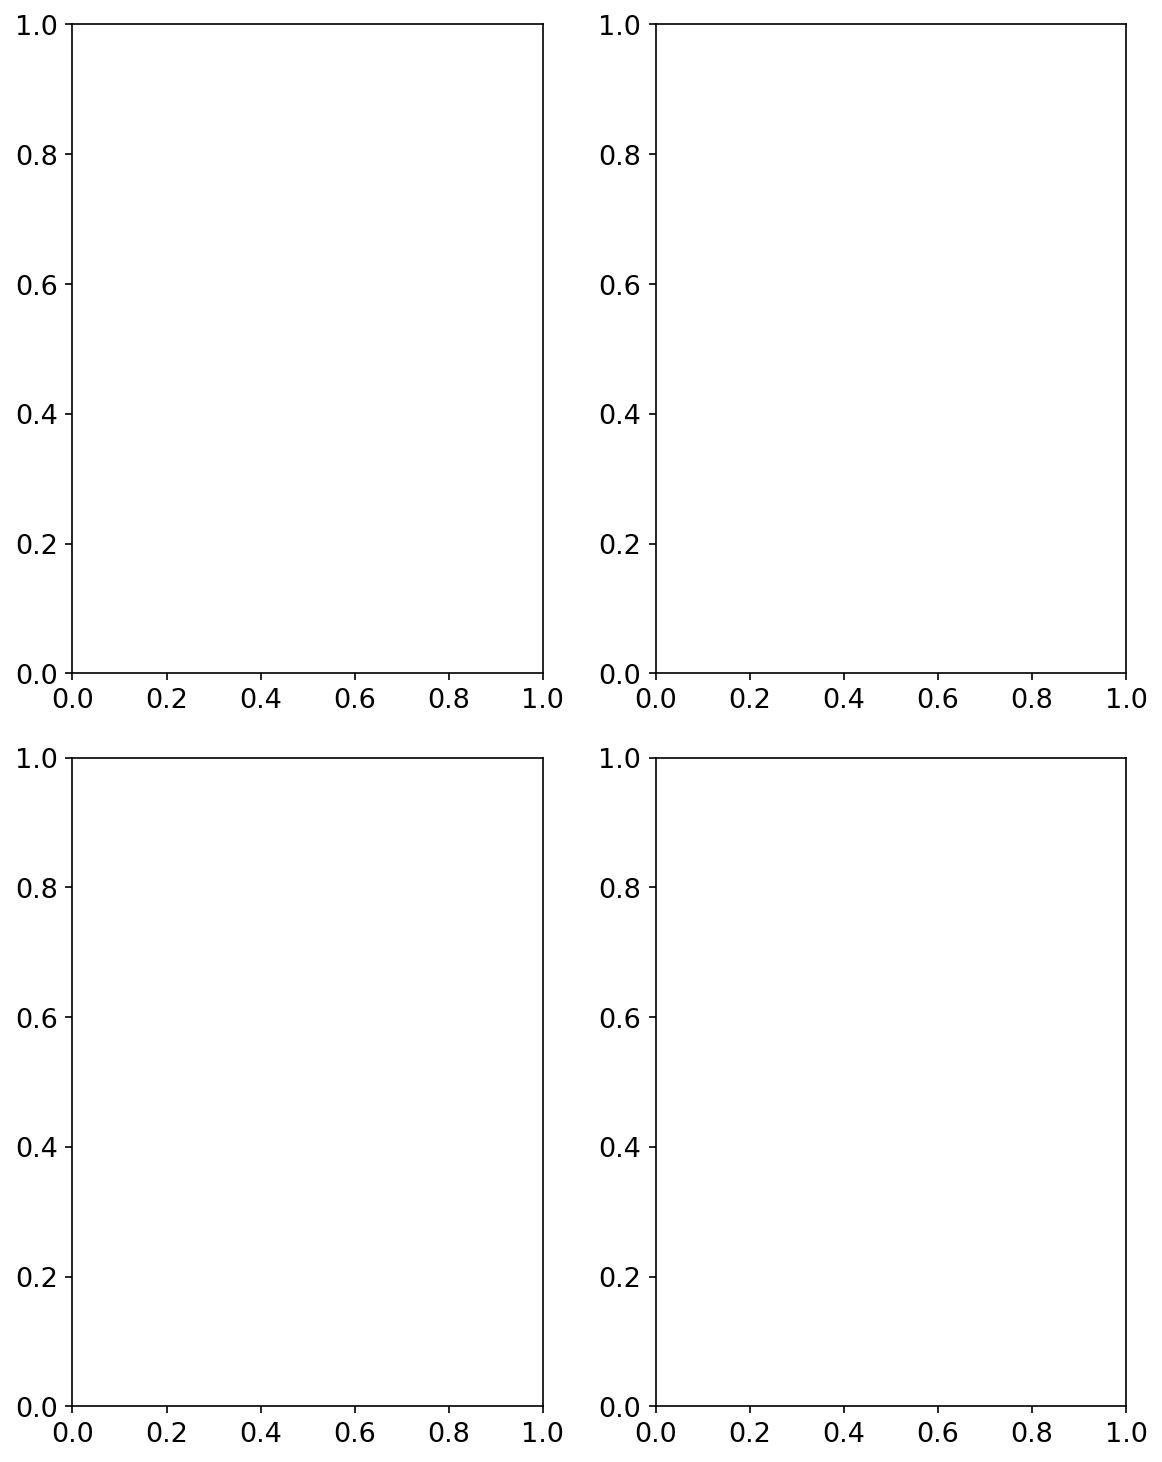

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.5,
    "lines.markersize": 7
})

## Display the final figures


Displaying: ml_corrected_outputs\parity_plots.png


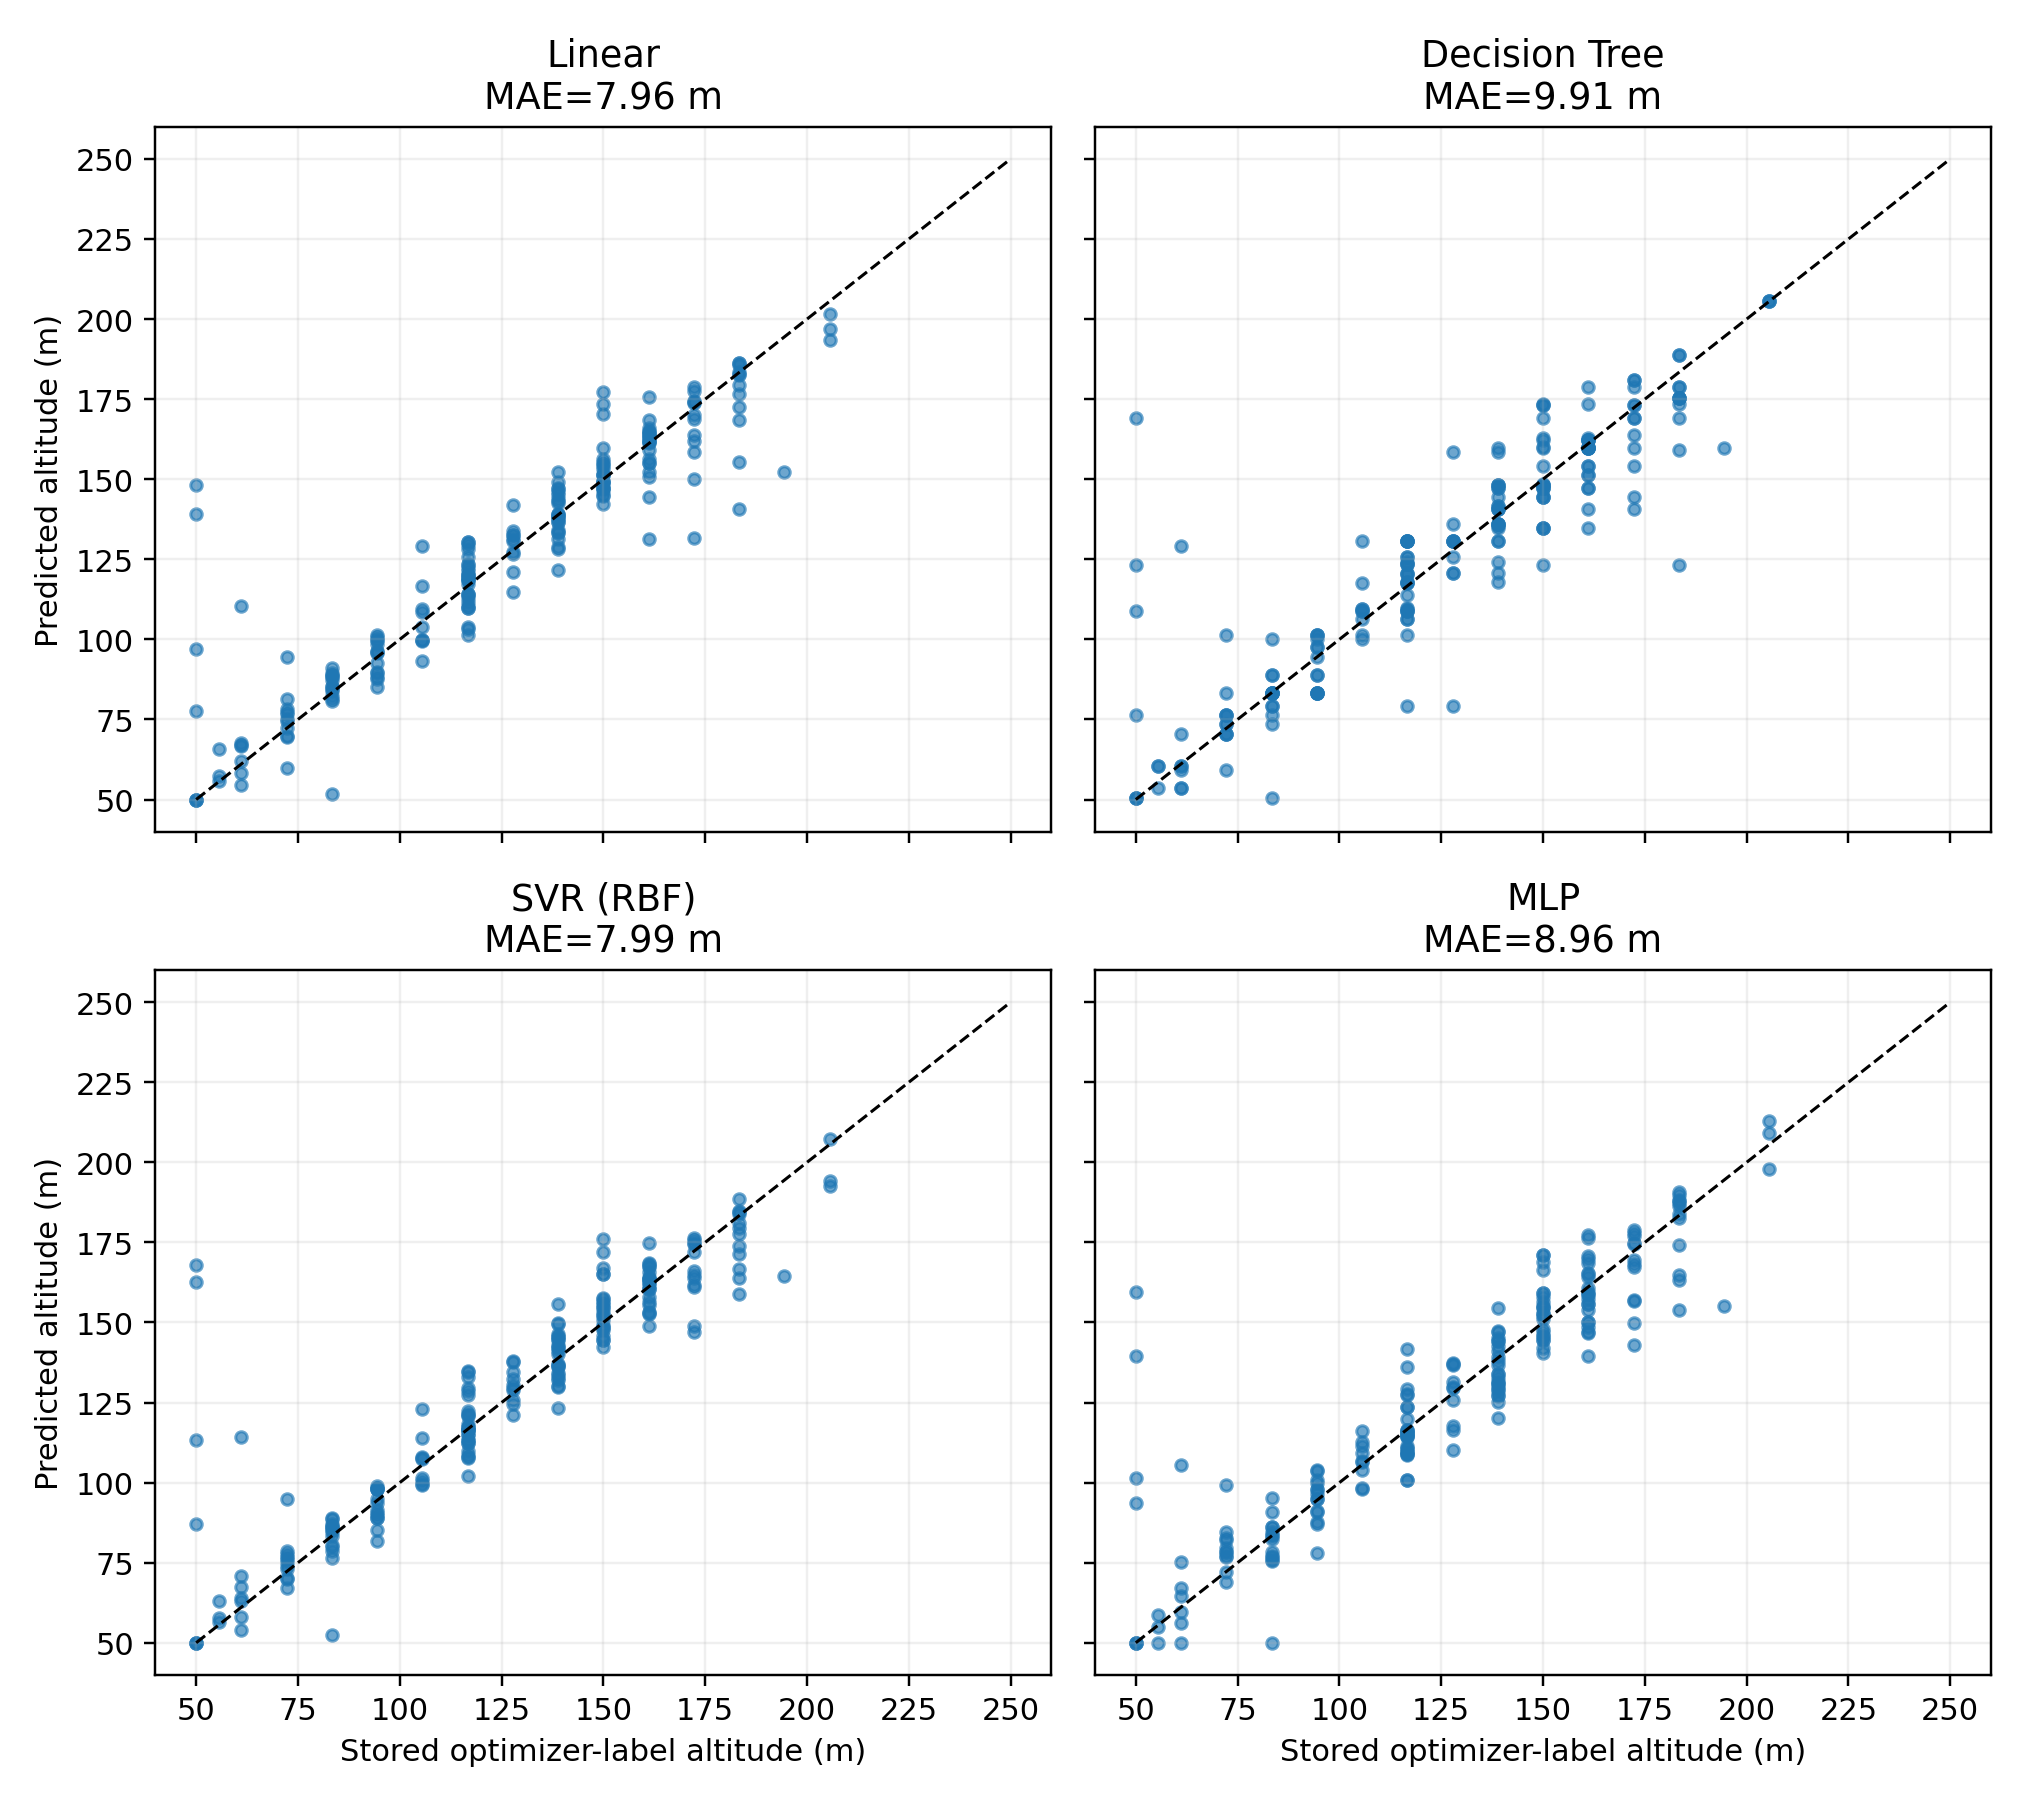

Displaying: ml_corrected_outputs\gap_distributions.png


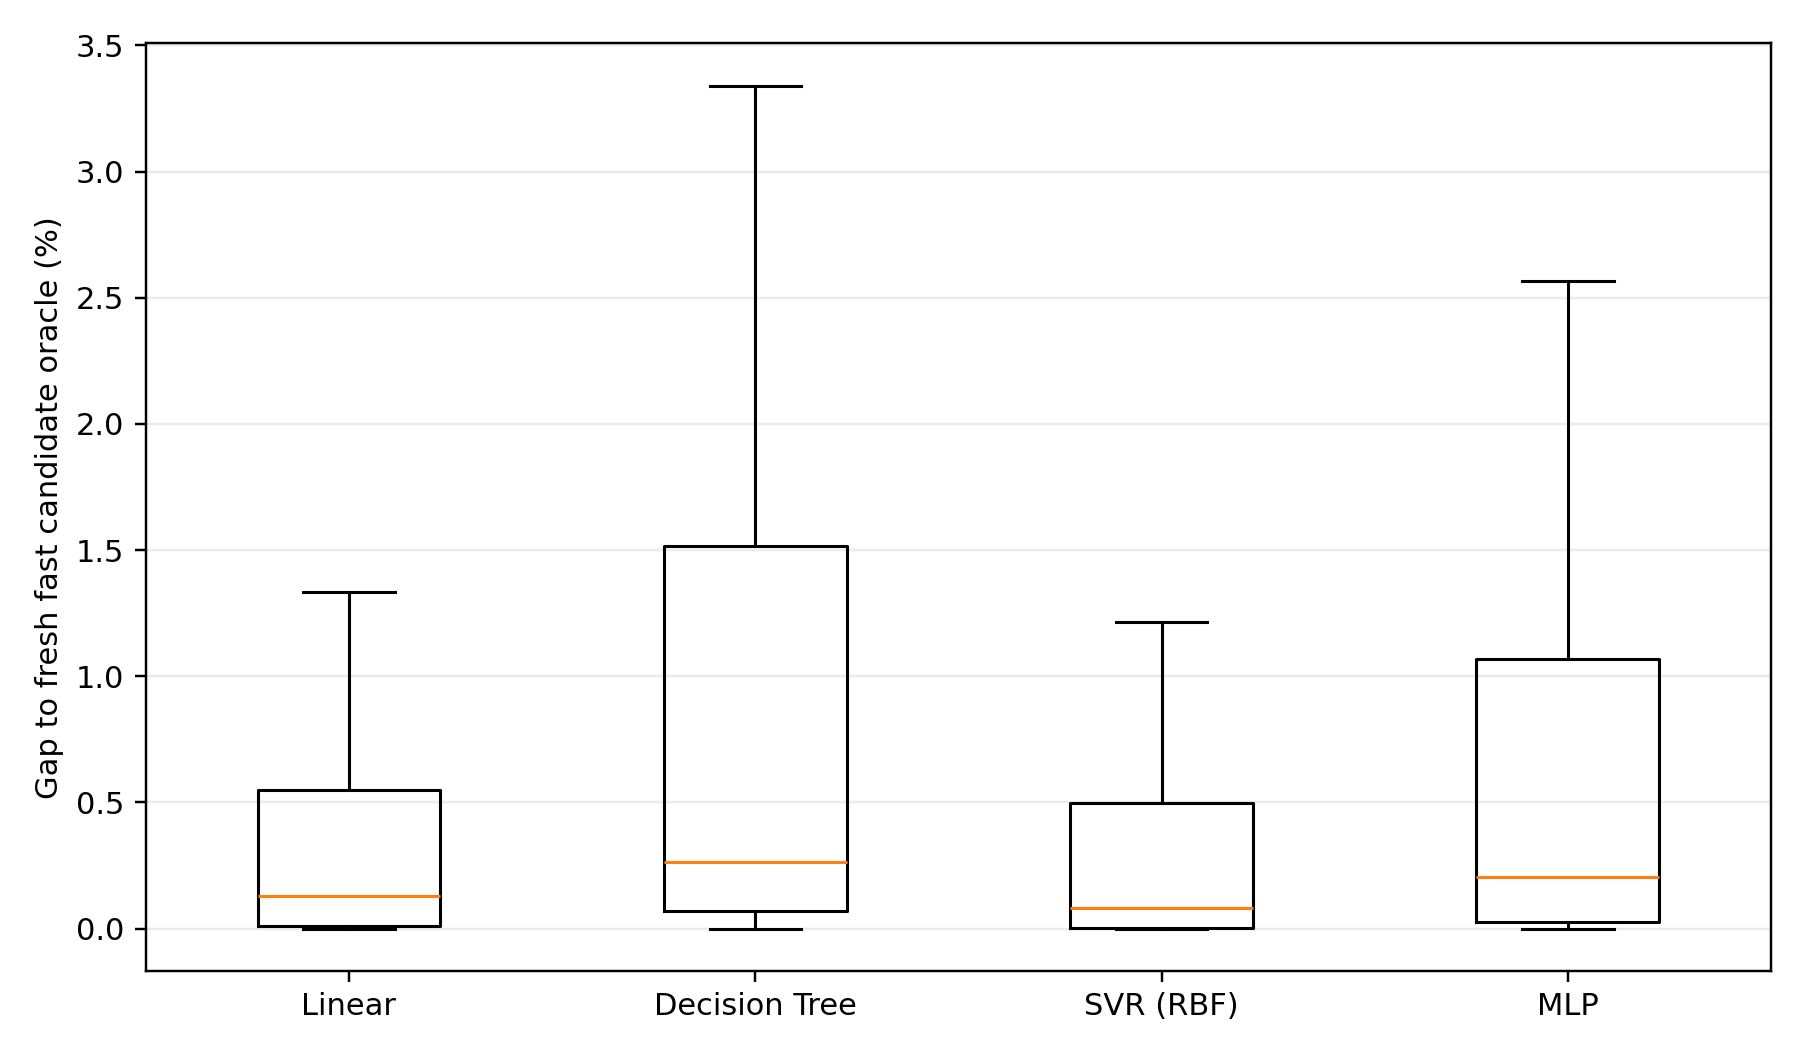

Displaying: ml_corrected_outputs\mae_vs_gap.png


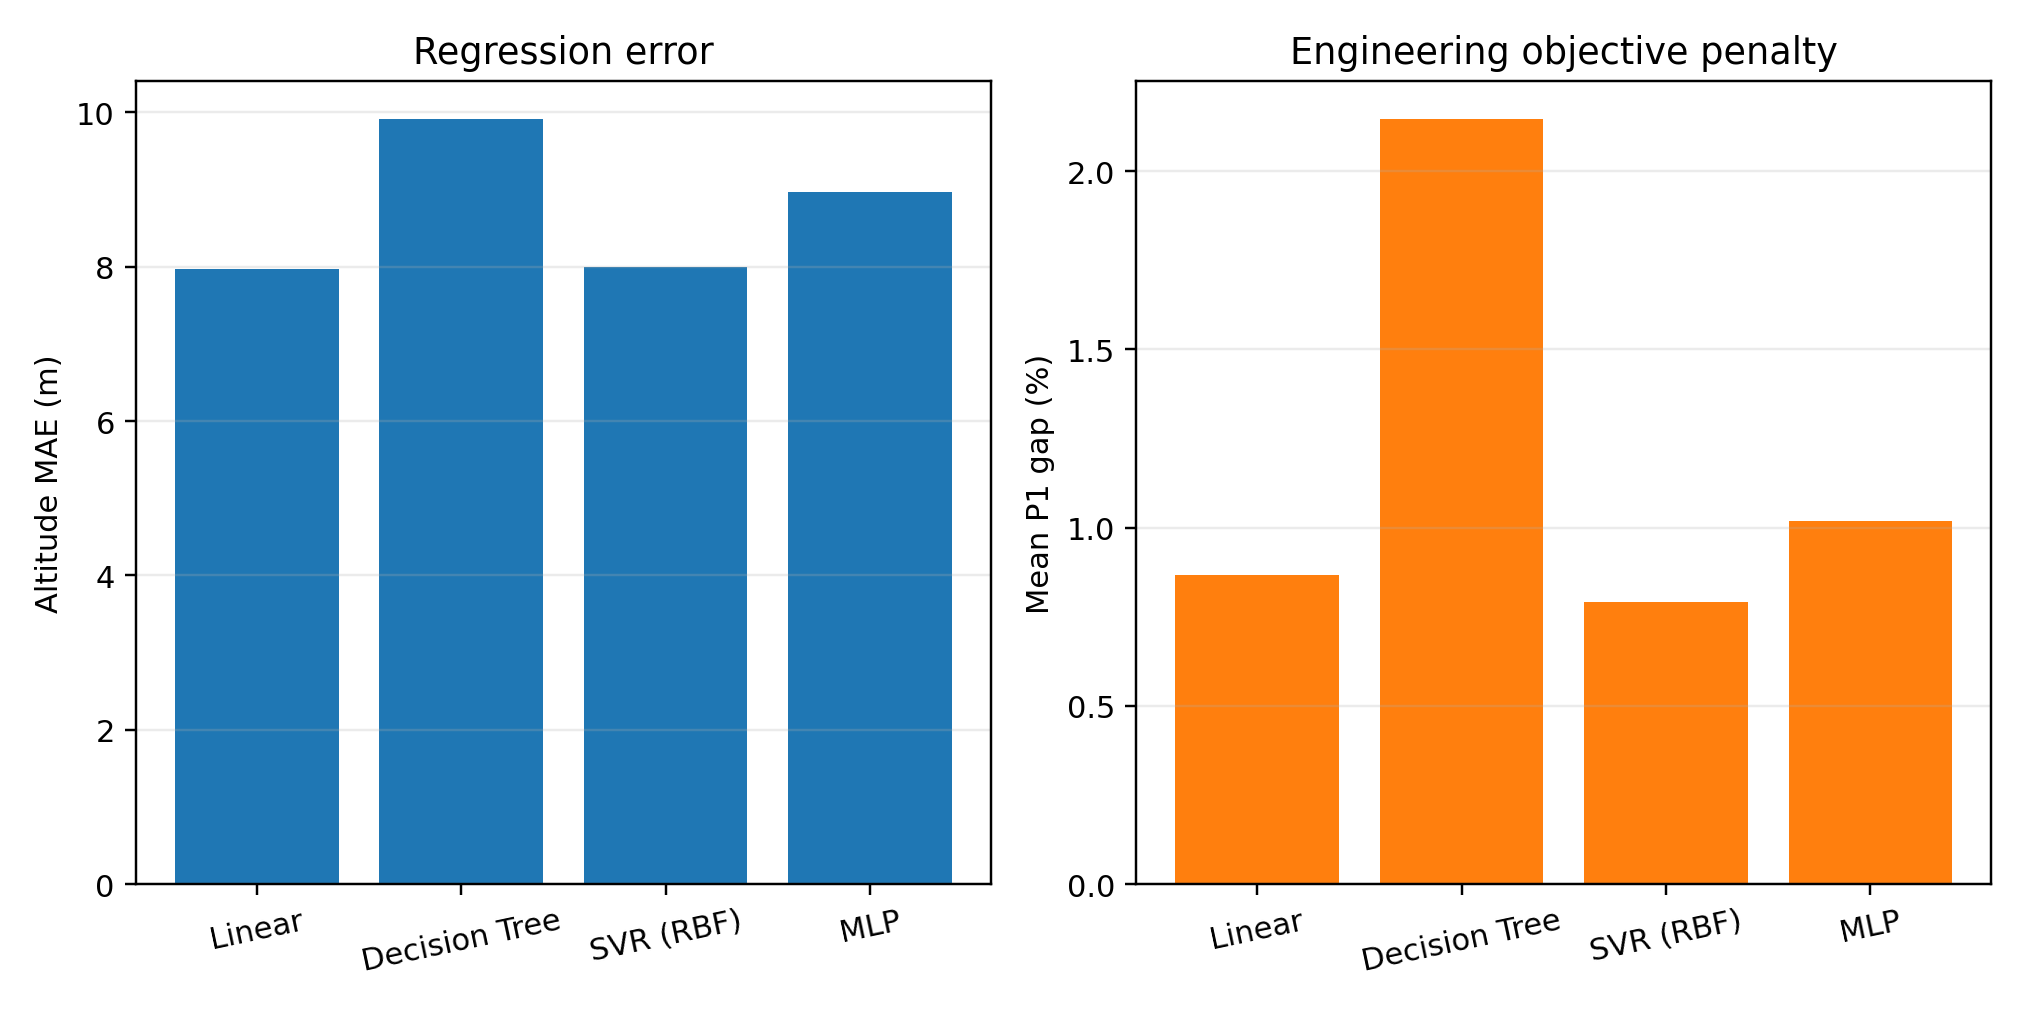

Displaying: ml_corrected_outputs\svr_permutation_importance.png


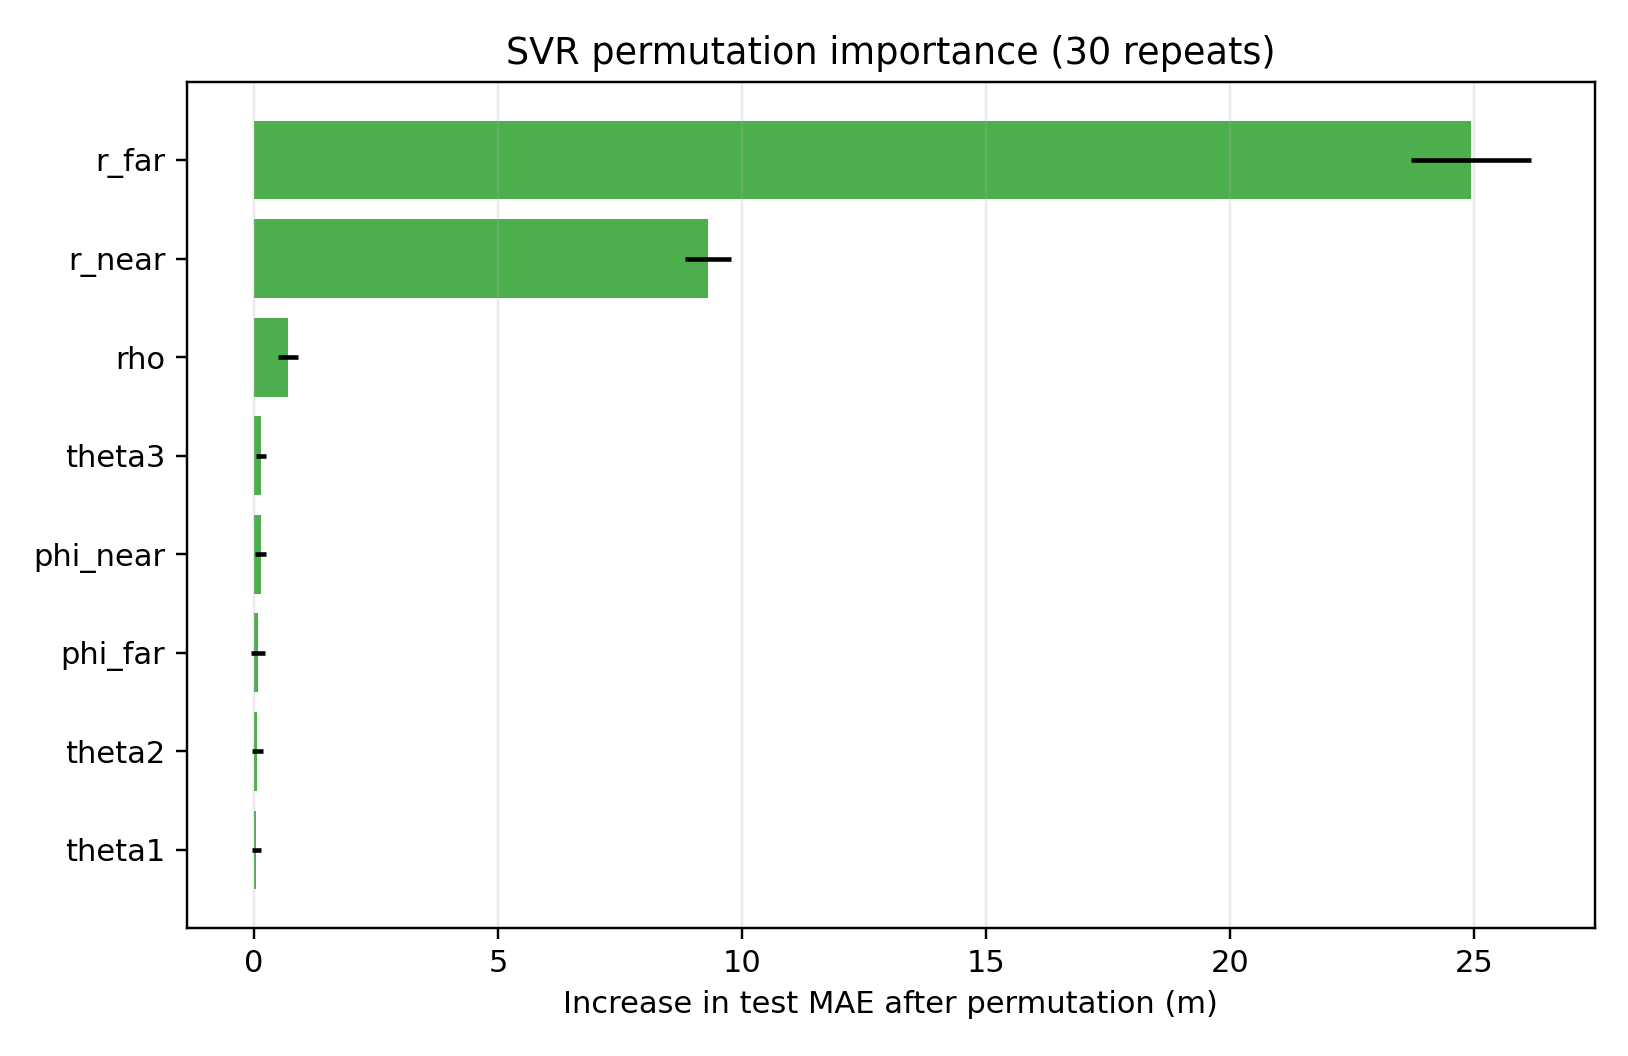

Displaying: gap1_outputs_paper_grid\gap1_objective_comparison.png


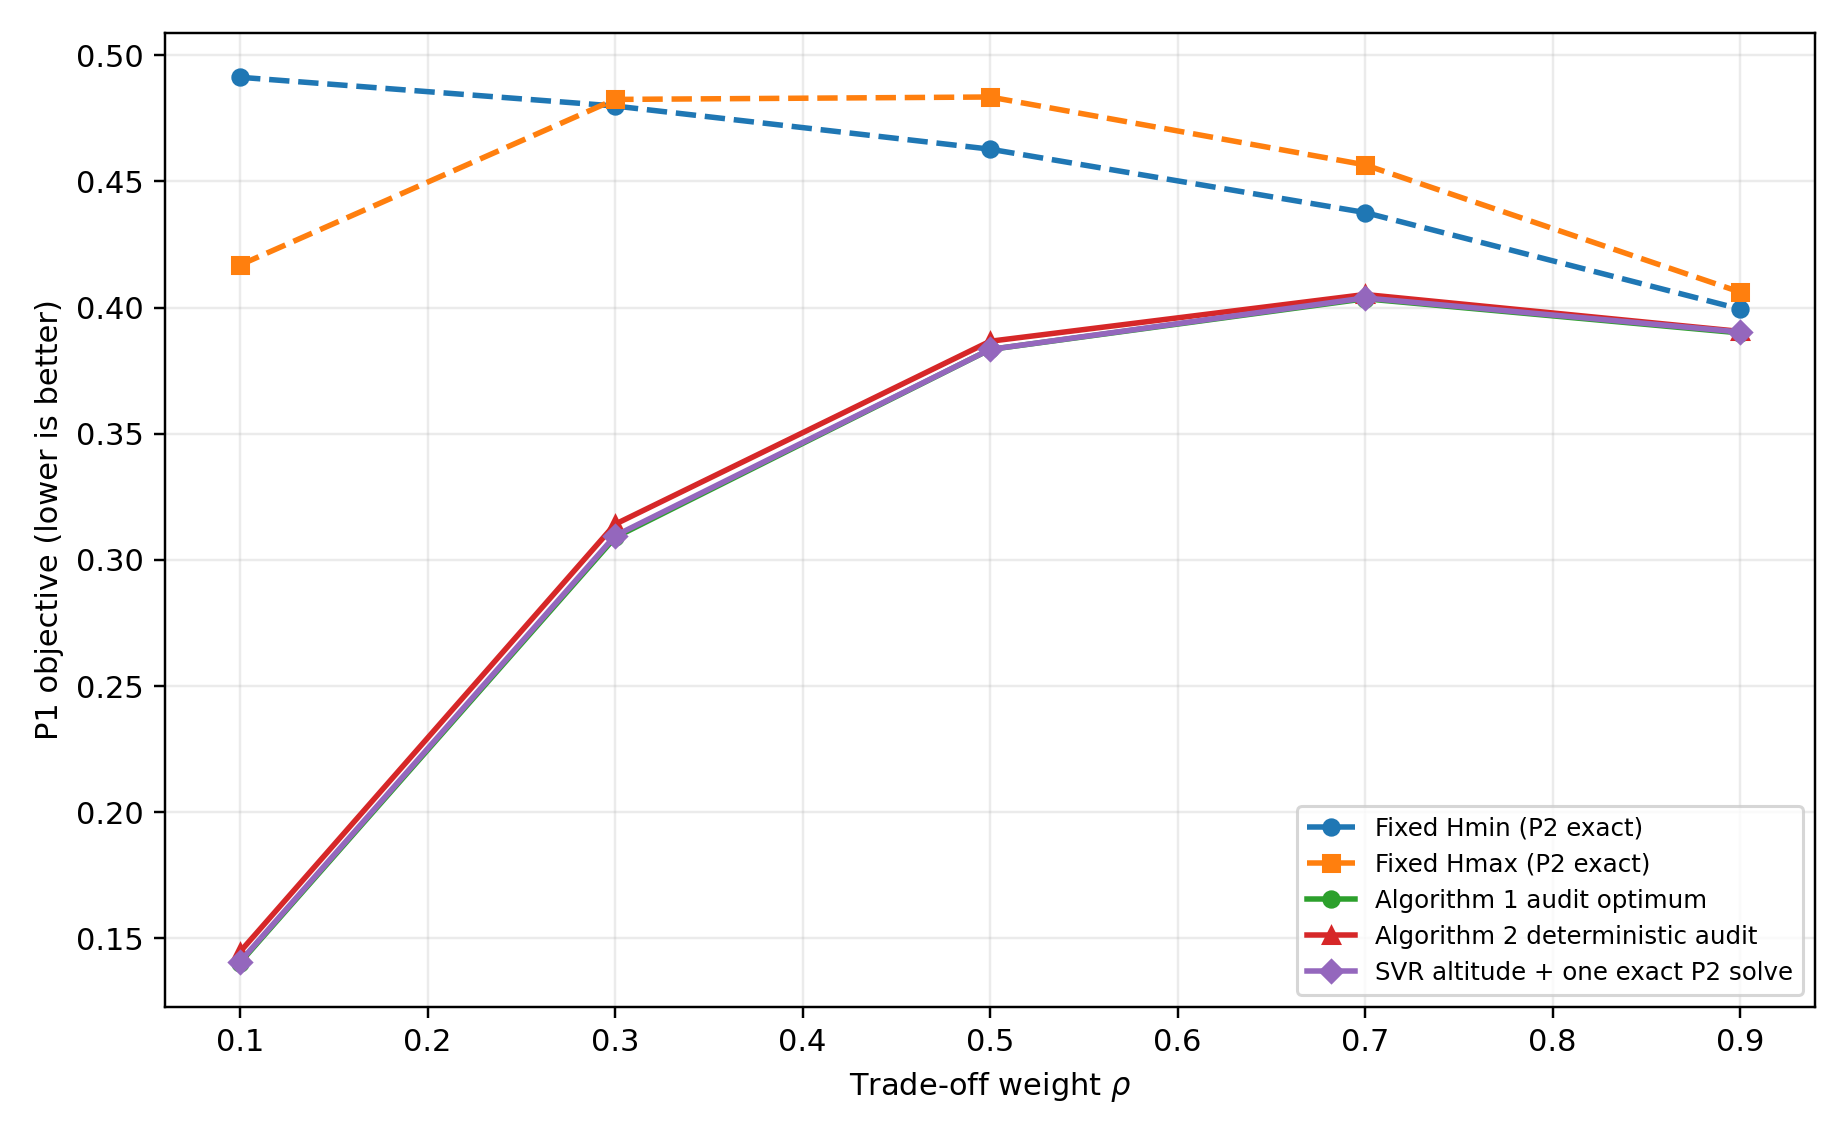

In [1]:
from pathlib import Path
from IPython.display import Image, display

figure_paths = [
    Path("../results/ml/parity_plots.png"),
    Path("../results/ml/gap_distributions.png"),
    Path("../results/ml/mae_vs_gap.png"),
    Path("../results/ml/svr_permutation_importance.png"),
    Path("gap1_outputs_paper_grid/gap1_objective_comparison.png"),
]

for path in figure_paths:
    if path.exists():
        print(f"Displaying: {path}")
        display(Image(filename=str(path)))
    else:
        print(f"Not found: {path}")

## Full reproducibility order

For a clean, full recomputation use this order:

1. fast-solver audit;
2. stored-label audit;
3. complete ML evaluation;
4. five repeated splits;
5. 0.1-degree Kang benchmark, refitting the same canonicalized final SVR
   (`C=300`, `gamma=0.03`, `epsilon=4`) used in the ML analysis;
6. `verify_gap1.py` and `validate_report_claims.py` after the expected audit files are present.

The literal 73-SDP Algorithm 1 PSO sweep is intentionally not triggered automatically. It is expensive and its saved output is included in `gap1_outputs_paper_grid/exact_alg1_pso_sweep.json`.


In [20]:

RUN_FINAL_VERIFICATION = False
if RUN_FINAL_VERIFICATION:
    subprocess.run([sys.executable, "verify_gap1.py"], check=True)
    subprocess.run([sys.executable, "validate_report_claims.py"], check=True)
else:
    print("Set RUN_FINAL_VERIFICATION=True after the required output files exist.")


Set RUN_FINAL_VERIFICATION=True after the required output files exist.


## Final interpretation

The deployed surrogate predicts only altitude. The covariance and scaling factor are still obtained by one exact fixed-altitude SDP, so PSD and per-antenna constraints are enforced after every ML prediction. SVR is the default because it has the best five-split altitude MAE and the best mean/median/p95 downstream gap in the 200-case common-oracle audit. The small exact 20-case subset favoring MLP is retained as sensitivity evidence rather than hidden.


## Additional SVR Diagnostics
Learning-curve and residual analyses for the locked RBF-SVR model.

In [27]:
%run ../scripts/render_svr_diagnostics.py

{
  "dataset": "ds3.npz",
  "split": {
    "train": 800,
    "test": 200,
    "seed": 42
  },
  "model": {
    "kernel": "rbf",
    "C": 300.0,
    "gamma": 0.03,
    "epsilon": 4.0
  },
  "residuals": {
    "mean_m": -1.9701888727461843,
    "std_m": 15.532525644171521,
    "median_absolute_m": 4.681009649953943,
    "p95_absolute_m": 23.509052057446155
  },
  "learning_curve": [
    {
      "train_size": 96,
      "train_mae_m": 5.901686058003721,
      "cv_mae_mean_m": 10.328119524068791,
      "cv_mae_std_m": 1.4032117118324945
    },
    {
      "train_size": 204,
      "train_mae_m": 6.313606231596973,
      "cv_mae_mean_m": 8.802008881504552,
      "cv_mae_std_m": 1.0764387937252855
    },
    {
      "train_size": 313,
      "train_mae_m": 6.5886330290805,
      "cv_mae_mean_m": 8.44898602911386,
      "cv_mae_std_m": 1.1681318586965495
    },
    {
      "train_size": 422,
      "train_mae_m": 6.572669140033173,
      "cv_mae_mean_m": 8.138078343746528,
      "cv_mae_std_m": 1